In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys, os
from utils import *
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.insert(0, project_root)
from atow_estimation.paths import INTERIM_DATA_DIR

In [3]:
warnings.filterwarnings("ignore", category=pd.errors.SettingWithCopyWarning)
pd.set_option('display.max_columns', None)

In [4]:
# data = pd.read_csv('initial_preprocessed_dataset.csv')
data = pd.read_csv("data_with_full_climbing_vel.csv")
data = process_data_model_2(data)

Rows with nan features dropped: 2


In [5]:
data.info(verbose=True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
Index: 28357 entries, 0 to 28358
Data columns (total 50 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ADEPLat                   28357 non-null  float64
 1   ADEPLong                  28357 non-null  float64
 2   ADESLat                   28357 non-null  float64
 3   ADESLong                  28357 non-null  float64
 4   routeType                 28357 non-null  object 
 5   aircraftType              28357 non-null  object 
 6   airlineCode               28357 non-null  object 
 7   tow                       28357 non-null  float64
 8   flightType                28357 non-null  object 
 9   wake                      28357 non-null  object 
 10  RECATwake                 28357 non-null  object 
 11  numberOfEngines           28357 non-null  float64
 12  cruiseSpeed               28357 non-null  float64
 13  cruiseLevel               28357 non-null  float64
 14  ATOT_track_

# EDA

In [6]:
categorical_variables = ['routeType', 'flightType', 'wake', 'RECATwake', 'numberOfEngines', 'aircraftType', 'airlineCode']

numeric_cols = data.select_dtypes(include=['int64', 'float64']).columns.difference(categorical_variables)

# general statistics

In [157]:
# non_null_count = data.count()
# dtypes = data.dtypes

# # Generate descriptive statistics for numeric columns and select only count, mean, std, min, and max
# desc_stats = data.describe(percentiles=[0.25, 0.5, 0.75]).T[['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max']]

# # Combine non-null count, dtype, and the descriptive statistics into one DataFrame
# summary_df = pd.DataFrame({
#     'Non-null Count': non_null_count,
#     'Dtype': dtypes
# }).join(desc_stats)
# summary_df

# duplicates

In [158]:
data.duplicated().sum()

0

# categorical variables

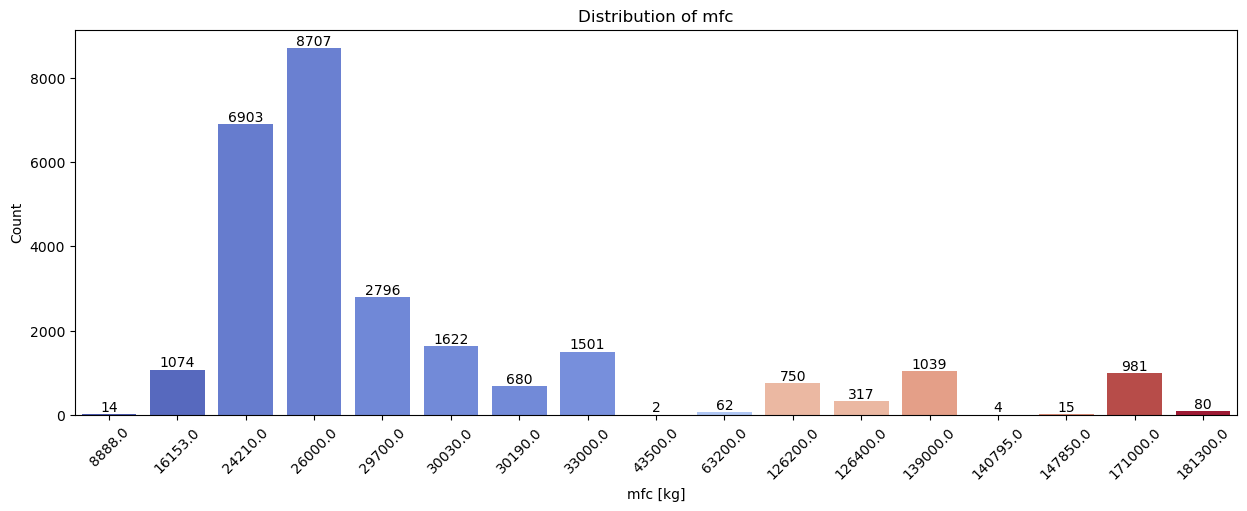

In [159]:
# col = 'wake'
# plt.figure(figsize=(15, 5))
# order = sorted(data[col].dropna().unique())
# sns.countplot(data=data, x=col, hue=col, legend=False, order=order, palette="coolwarm")        
# plt.title(f"Distribution of {col}")
# plt.xlabel(col)
# plt.ylabel("Count")        
# if data[col].nunique() > 50:
#     plt.xticks([])
# else:
#     plt.xticks(rotation=45)
# plt.show()

col = 'mfc'
plt.figure(figsize=(15, 5))
order = sorted(data[col].dropna().unique())
ax = sns.countplot(data=data, x=col, hue=col, legend=False, order=order, palette="coolwarm")        
plt.title(f"Distribution of {col}")
plt.xlabel(col)
plt.ylabel("Count")
plt.xlabel(f"{col} [kg]")

# Loop over each patch (bar) and add a text annotation for the count
for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width() / 2, height + 0.5, int(height), 
            ha='center', va='bottom')

if data[col].nunique() > 50:
    plt.xticks([])
else:
    plt.xticks(rotation=45)
plt.show()


In [160]:
data['mtow'].dtype

dtype('int64')

/tmp/ipykernel_24167/2537571928.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=cat_col, y='tow', data=filtered_data, palette="Set3")


<Figure size 1200x600 with 0 Axes>

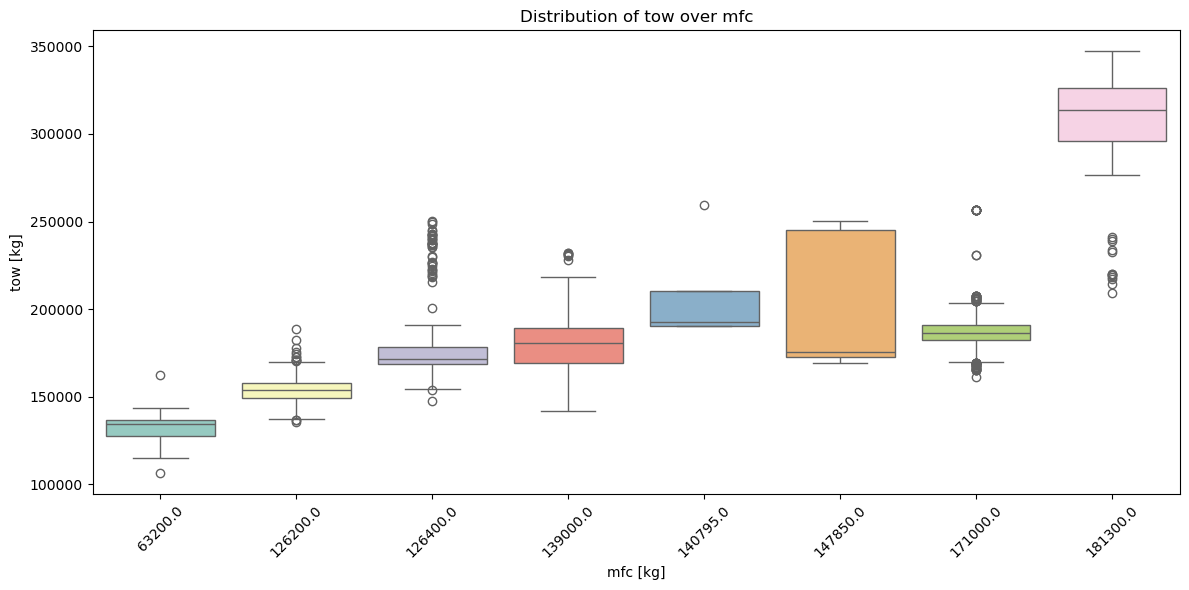

In [161]:
cat_col = 'mfc'
plt.figure(figsize=(12, 6))

# Filter the data first
filtered_data = data[data[cat_col] > 43500]

# Create the boxplot
plt.figure(figsize=(12, 6))
sns.boxplot(x=cat_col, y='tow', data=filtered_data, palette="Set3")

plt.title(f"Distribution of tow over {cat_col}")
plt.ylabel("tow [kg]")
plt.xlabel(f"{cat_col} [kg]")
if filtered_data[cat_col].nunique() > 50:
    plt.xticks([])
else:
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

/tmp/ipykernel_24167/3396370336.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=cat_col, y='tow', data=data, palette="Set3")


<Figure size 1200x600 with 0 Axes>

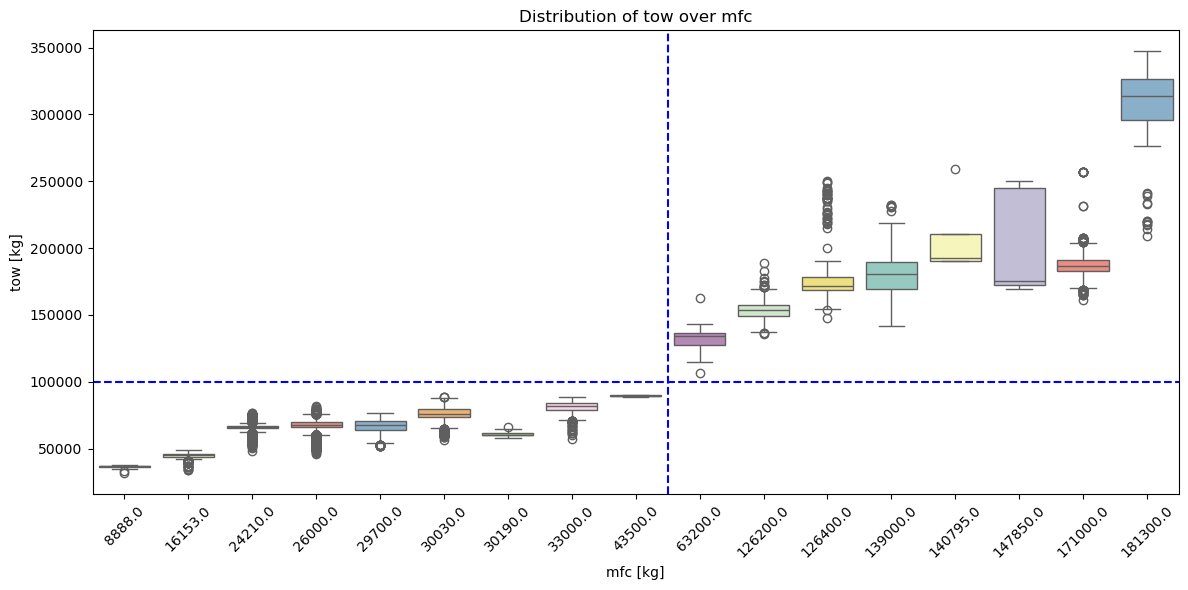

In [162]:
# cat_col = 'mtow'
# plt.figure(figsize=(12, 6))
# order = sorted(data[data[cat_col] < 158700][cat_col].dropna().unique())
# sns.boxplot(x=data[data[cat_col] < 158700][cat_col], hue=data[data[cat_col] <= 158700][cat_col], y=data['tow'], order=order, palette="Set3", legend=False)
# plt.xticks(rotation=45)
# plt.title(f"Distribution of tow over {cat_col}")
# if data[cat_col].nunique() > 50:
#     plt.xticks([])
# else:
#     plt.xticks(rotation=45)
# plt.show()

cat_col = 'mfc'
plt.figure(figsize=(12, 6))

# Filter the data first
# filtered_data = data[data[cat_col] >= 63200]

# Create the boxplot
plt.figure(figsize=(12, 6))
sns.boxplot(x=cat_col, y='tow', data=data, palette="Set3")

# # Add a horizontal line at a specified y-value
horizontal_line_value = 100000  # Change this to your desired y-value
plt.axhline(y=horizontal_line_value, color='b', linestyle='--', label=f'Horizontal line at {horizontal_line_value}')

# Add a vertical line at a specified x-value
vertical_line_value = 8.5  # Change this to your desired x-position (index)
plt.axvline(x=vertical_line_value, color='b', linestyle='--', label=f'Vertical line at index {vertical_line_value}')

plt.title(f"Distribution of tow over {cat_col}")
plt.ylabel("tow [kg]")
plt.xlabel(f"{cat_col} [kg]")
if data[cat_col].nunique() > 50:
    plt.xticks([])
else:
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

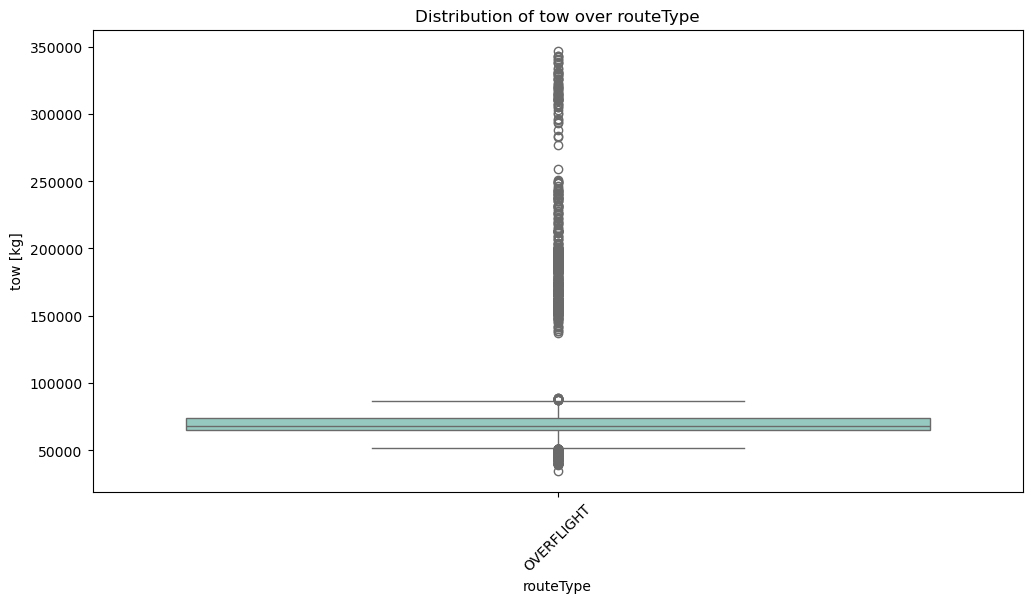

In [163]:
cat_col = 'routeType'
plt.figure(figsize=(12, 6))
order = sorted(data[data[cat_col] == 'OVERFLIGHT'][cat_col].dropna().unique())
sns.boxplot(x=data[data[cat_col] == 'OVERFLIGHT'][cat_col], hue=data[data[cat_col] == 'OVERFLIGHT'][cat_col], y=data['tow'], order=order, palette="Set3", legend=False)
plt.xticks(rotation=45)
plt.ylabel("tow [kg]")
plt.title(f"Distribution of tow over {cat_col}")
if data[cat_col].nunique() > 50:
    plt.xticks([])
else:
    plt.xticks(rotation=45)
plt.show()

In [164]:
def plot_categorical_counts(df, categorical_columns, category_threshold=50):
    for col in categorical_columns:
        plt.figure(figsize=(15, 5))
        order = sorted(df[col].dropna().unique())
        sns.countplot(data=df, x=col, hue=col, legend=False, order=order, palette="coolwarm")        
        plt.title(f"Distribution of {col}")
        plt.xlabel(col)
        plt.ylabel("Count")        
        if df[col].nunique() > category_threshold:
            plt.xticks([])
        else:
            plt.xticks(rotation=45)
        plt.show()
        
def plot_boxplots(df, categorical_columns, category_threshold=50):
    for cat_col in categorical_columns:
        plt.figure(figsize=(15, 5))
        order = sorted(df[cat_col].dropna().unique())
        sns.boxplot(x=df[cat_col], hue=df[cat_col], y=df['tow'], order=order, palette="Set3", legend=False)
        plt.xticks(rotation=45)
        plt.title(f"Distribution of tow over {cat_col}")
        if df[cat_col].nunique() > category_threshold:
            plt.xticks([])
        else:
            plt.xticks(rotation=45)
        plt.show()        

/tmp/ipykernel_24167/1754070049.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='aircraftType', y='tow', data=filtered_data,


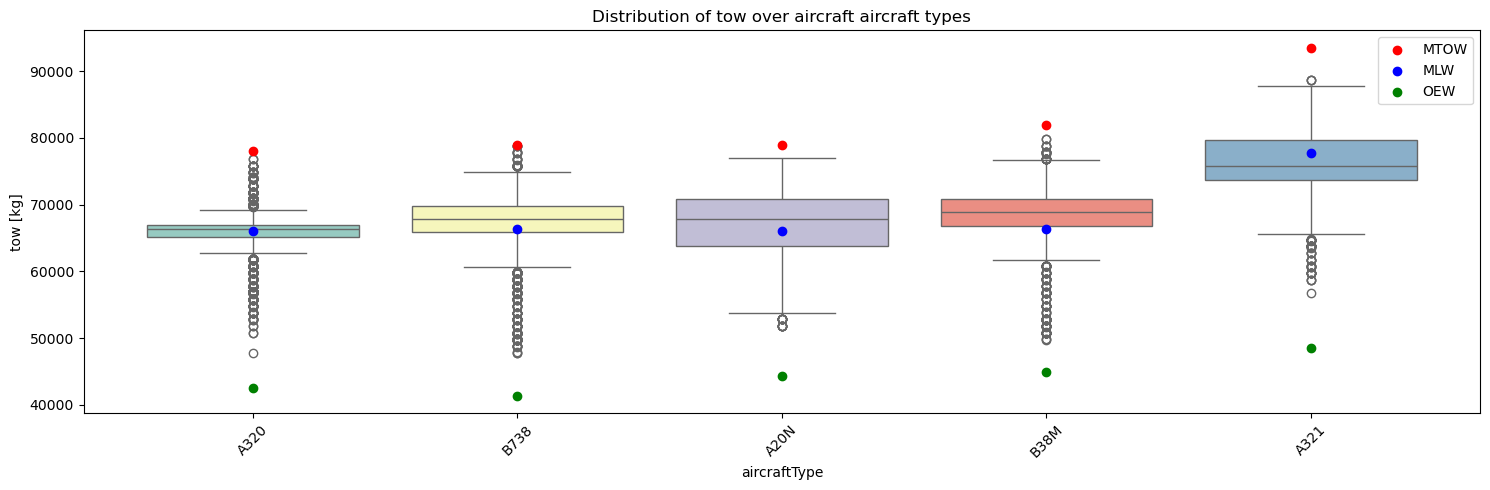

In [165]:
top_aircrafts = data['aircraftType'].value_counts().nlargest(5).index
filtered_data = data[data['aircraftType'].isin(top_aircrafts)]

# Determine order of aircraft types as in boxplot
aircraft_order = filtered_data['aircraftType'].value_counts().loc[top_aircrafts].index.tolist()

# Get unique mtow value per aircraftType from filtered_data
mtow_values = filtered_data[['aircraftType', 'mtow']].drop_duplicates('aircraftType')
mtow_values = mtow_values.set_index('aircraftType').loc[aircraft_order]

mlw_values = filtered_data[['aircraftType', 'mlw']].drop_duplicates('aircraftType')
mlw_values = mlw_values.set_index('aircraftType').loc[aircraft_order]

oew_values = filtered_data[['aircraftType', 'oew']].drop_duplicates('aircraftType')
oew_values = oew_values.set_index('aircraftType').loc[aircraft_order]

# Plot boxplot
plt.figure(figsize=(15, 5))
sns.boxplot(x='aircraftType', y='tow', data=filtered_data, 
            palette="Set3", order=aircraft_order)

# Overlay MTOW values as red dots
plt.scatter(x=range(len(mtow_values)), y=mtow_values['mtow'], 
            color='red', marker='o', label='MTOW', zorder=10)

# Overlay MLW values as red dots
plt.scatter(x=range(len(mlw_values)), y=mlw_values['mlw'], 
            color='blue', marker='o', label='MLW', zorder=10)

# Overlay MLW values as red dots
plt.scatter(x=range(len(oew_values)), y=oew_values['oew'], 
            color='green', marker='o', label='OEW', zorder=10)

# Final touches
plt.xticks(ticks=range(len(aircraft_order)), labels=aircraft_order, rotation=45)
plt.title("Distribution of tow over aircraft aircraft types")
plt.ylabel("tow [kg]")
plt.xlabel("aircraftType")
plt.legend()
plt.tight_layout()
plt.show()

In [128]:
# plot_categorical_counts(data, categorical_feat)

In [129]:
# plot_boxplots(data, categorical_feat)

# numerical variables

In [130]:
def summarize_numerical_features(df):
    return df.describe().transpose()

def plot_numerical_distributions(df, numerical_columns, bins=30):
    for col in numerical_columns:
        plt.figure(figsize=(8, 4))
        sns.histplot(df[col], bins=bins, kde=True, color="blue")
        plt.title(f"Distribution of {col}")
        plt.xlabel(col)
        plt.ylabel("Number of flights")
        plt.show()
        
def plot_boxplots_num(df, numerical_columns):
    for col in numerical_columns:
        plt.figure(figsize=(8, 4))
        sns.boxplot(y=df[col], color="orange")
        plt.title(f"{col} boxplot")
        plt.ylabel(col)
        plt.show()
        
def plot_pairplot(df, numerical_columns):
    sns.pairplot(df[numerical_columns], diag_kind="kde", plot_kws={'alpha':0.5})
    plt.show()
    
def plot_correlation_heatmap(df, numerical_columns):
    plt.figure(figsize=(10, 6))
    sns.heatmap(df[numerical_columns].corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
    plt.title("Matriz de correlacion")
    plt.show()
    
def plot_scatter(df, x_col, y_col):
    plt.figure(figsize=(8, 5))
    sns.scatterplot(x=df[x_col], y=df[y_col], alpha=0.5)
    plt.title(f"Scatter Plot de {x_col} vs {y_col}")
    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.show()
    
def plot_missing_values(df):
    missing_values = df.isnull().mean() * 100
    missing_values = missing_values[missing_values > 0].sort_values()
    
    if missing_values.empty:
        print("No se han detectado valores nulos.")
        return
    
    plt.figure(figsize=(20, 5))
    sns.barplot(x=missing_values.index, hue=missing_values.index, y=missing_values.values, palette="Reds", legend=False)
    plt.xticks(rotation=45)
    plt.ylabel("Valores nulos (%)")
    plt.title("Porcentaje de valores nulos por variable")
    plt.show()

In [131]:
summarize_numerical_features(data[numerical_feat])

,count,mean,std,min,25%,50%,75%,max
ADEPLat,28359.0,47.559475,7.419053,5.254445,41.275280,50.780000,52.453890,6.769861e+01
ADEPLong,28359.0,-0.503923,22.639889,-118.400000,-6.270000,4.484445,8.570556,3.488556e+01
ADESLat,28359.0,40.618473,4.925555,-23.433330,38.282220,39.551670,41.296940,6.020278e+01
ADESLong,28359.0,-1.302433,10.943228,-97.033330,-4.499166,-0.558056,2.738889,3.488556e+01
cruiseSpeed,28359.0,442.294404,20.153196,276.000000,436.000000,443.000000,450.000000,5.300000e+02
cruiseLevel,28359.0,367.464156,27.301278,150.000000,360.000000,370.000000,390.000000,4.300000e+02
flight_duration,28359.0,2.964292,1.668959,1.111667,2.062500,2.400000,3.374583,1.347972e+01
CLIMB_duration,28359.0,0.344839,0.026465,0.053611,0.350000,0.350000,0.350000,6.108333e-01
CRUISE_duration,28359.0,2.162350,1.671106,0.296944,1.241528,1.621111,2.556944,1.267556e+01
DESCENT_duration,28359.0,0.457076,0.076516,0.028611,0.415278,0.445000,0.494167,1.238889e+00


Text(0.5, 1.0, 'Distribution of overall flight duration')

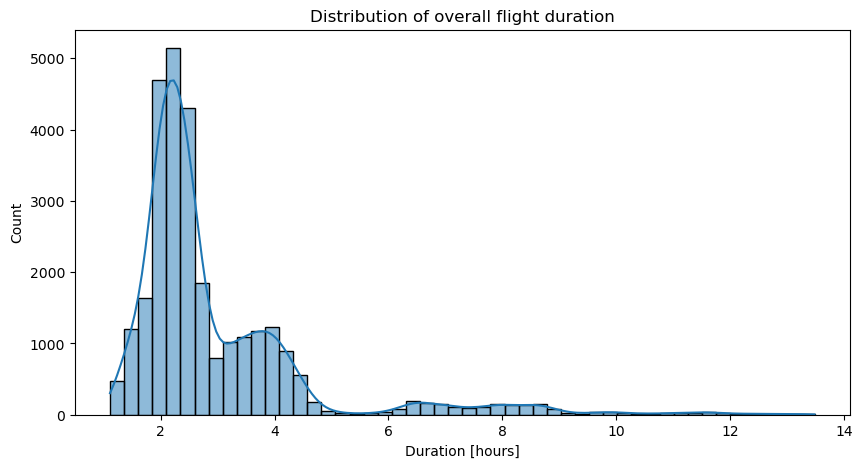

In [166]:
col = 'flight_duration'
plt.figure(figsize=(10, 5))
sns.histplot(data[col], bins=50, edgecolor='black', stat='count', kde=True)
plt.xlabel('Duration [hours]')
plt.ylabel('Count')
plt.title(f'Distribution of overall flight duration')

Text(0.5, 1.0, 'Distribution of total distance')

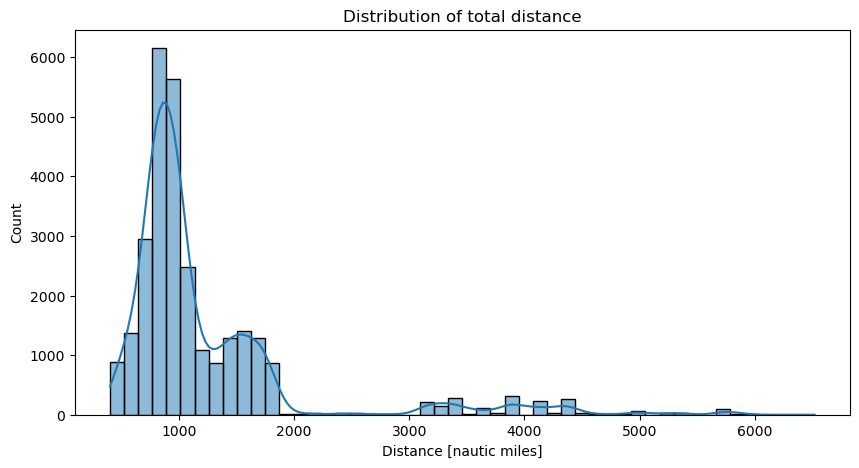

In [168]:
col = 'total_distance'
plt.figure(figsize=(10, 5))
sns.histplot(data[col], bins=50, edgecolor='black', stat='count', kde=True)
plt.xlabel('Distance [nautic miles]')
plt.ylabel('Count')
plt.title(f'Distribution of total distance')

In [134]:
# plot_numerical_distributions(data, numerical_feat)

In [135]:
# plot_boxplots_num(data, numerical_feat)

In [136]:
# plot_pairplot(data, numerical_feat)

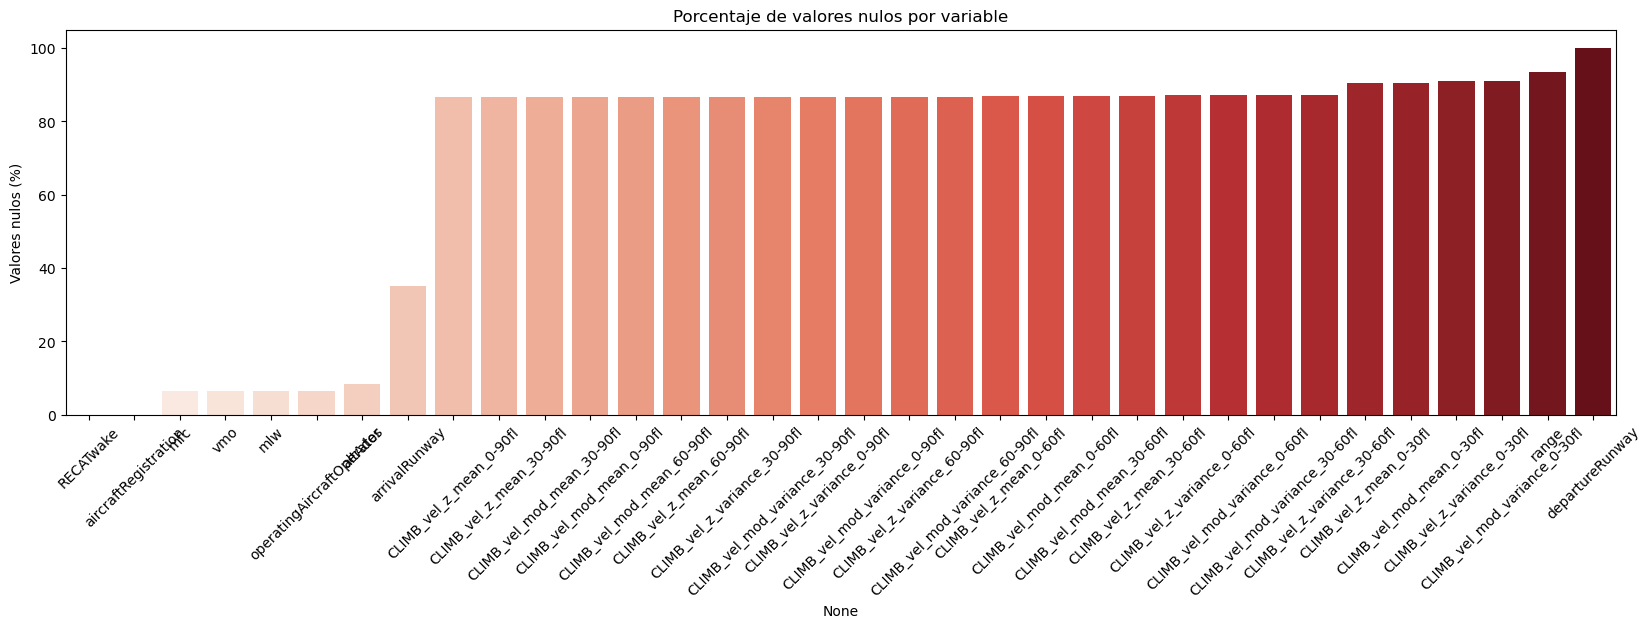

In [137]:
plot_missing_values(data)

# Correlations

## Pearson

In [7]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

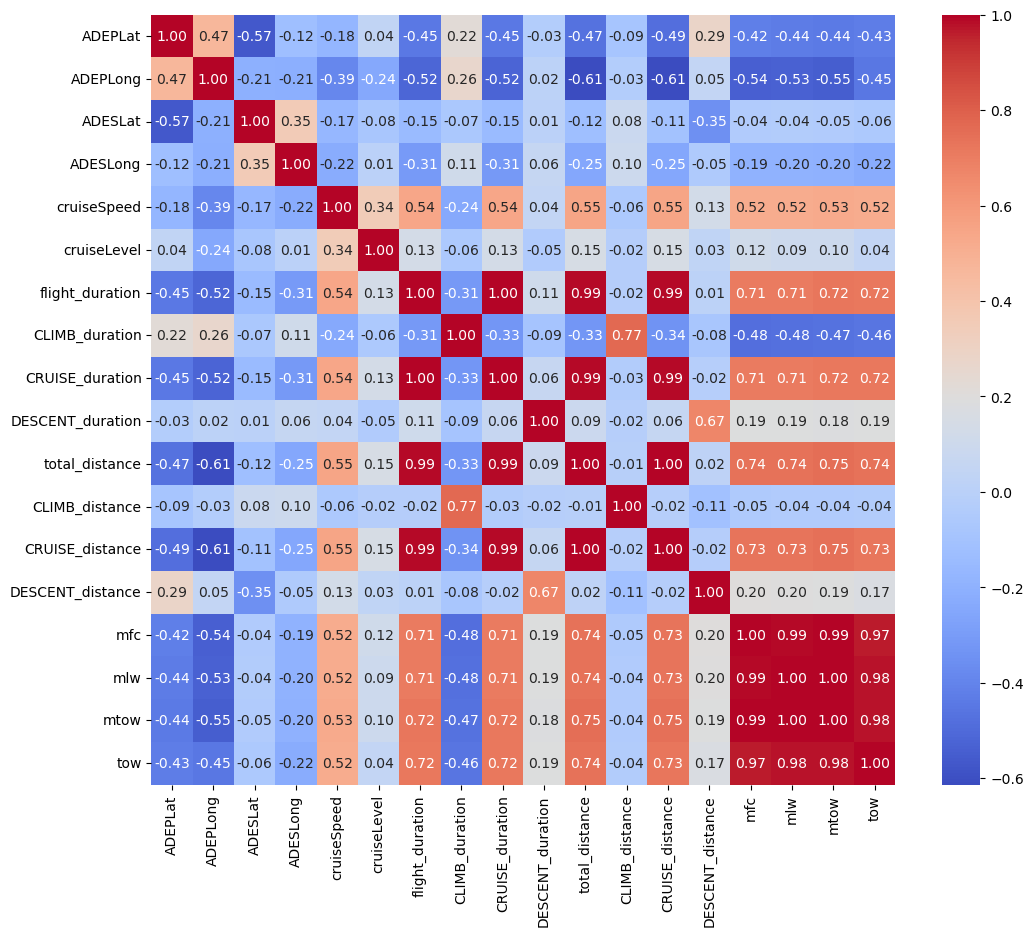

In [8]:
subset = ['ADEPLat', 'ADEPLong', 'ADESLat', 'ADESLong', 'cruiseSpeed', 'cruiseLevel', 'flight_duration', 'CLIMB_duration', 'CRUISE_duration', 'DESCENT_duration', 'total_distance', 'CLIMB_distance', 'CRUISE_distance', 'DESCENT_distance', 'mfc', 'mlw', 'mtow', 'tow']

data[subset] = scaler.fit_transform(data[subset])
pearson_corr = data[subset].corr(method='pearson')
plt.figure(figsize=(12, 10))
sns.heatmap(pearson_corr, annot=True, fmt=".2f", cmap="coolwarm")
# plt.title("Pearson Correlation Matrix")
plt.show()

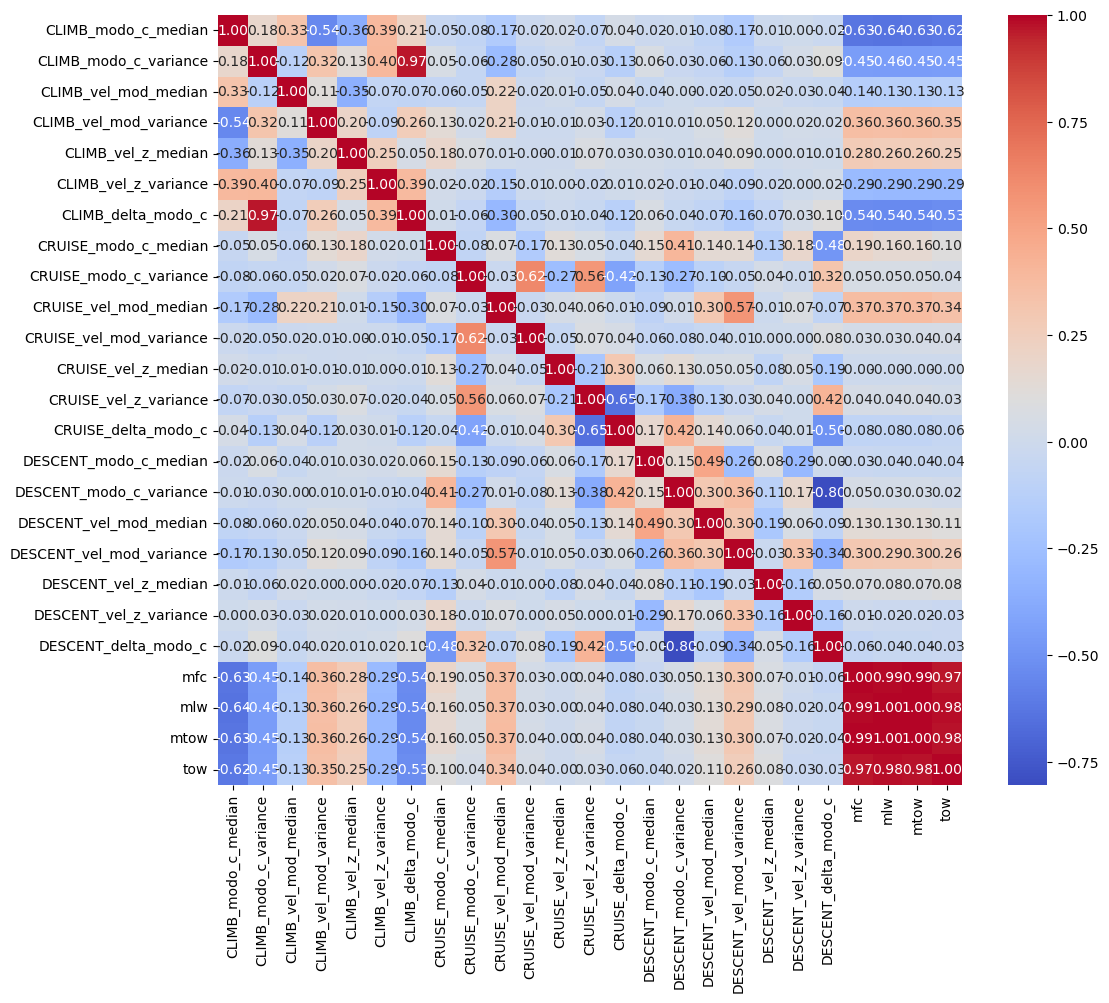

In [9]:
subset = ['CLIMB_modo_c_median', 'CLIMB_modo_c_variance', 'CLIMB_vel_mod_median', 'CLIMB_vel_mod_variance', 'CLIMB_vel_z_median', 'CLIMB_vel_z_variance', 'CLIMB_delta_modo_c', 'CRUISE_modo_c_median', 'CRUISE_modo_c_variance', 'CRUISE_vel_mod_median', 'CRUISE_vel_mod_variance', 'CRUISE_vel_z_median', 'CRUISE_vel_z_variance', 'CRUISE_delta_modo_c', 'DESCENT_modo_c_median', 'DESCENT_modo_c_variance', 'DESCENT_vel_mod_median', 'DESCENT_vel_mod_variance', 'DESCENT_vel_z_median', 'DESCENT_vel_z_variance', 'DESCENT_delta_modo_c', 'mfc', 'mlw', 'mtow', 'tow']

data[subset] = scaler.fit_transform(data[subset])
pearson_corr = data[subset].corr(method='pearson')
plt.figure(figsize=(12, 10))
sns.heatmap(pearson_corr, annot=True, fmt=".2f", cmap="coolwarm")
# plt.title("Pearson Correlation Matrix")
plt.show()

In [10]:
subset = [
 'CLIMB_vel_mod_mean_0_30fl',
 'CLIMB_vel_mod_variance_0_30fl',
 'CLIMB_vel_z_mean_0_30fl',
 'CLIMB_vel_z_variance_0_30fl',
 'CLIMB_vel_mod_mean_0_60fl',
 'CLIMB_vel_mod_variance_0_60fl',
 'CLIMB_vel_z_mean_0_60fl',
 'CLIMB_vel_z_variance_0_60fl',
 'CLIMB_vel_mod_mean_0_90fl',
 'CLIMB_vel_mod_variance_0_90fl',
 'CLIMB_vel_z_mean_0_90fl',
 'CLIMB_vel_z_variance_0_90fl',
 'CLIMB_vel_mod_mean_30_60fl',
 'CLIMB_vel_mod_variance_30_60fl',
 'CLIMB_vel_z_mean_30_60fl',
 'CLIMB_vel_z_variance_30_60fl',
 'CLIMB_vel_mod_mean_30_90fl',
 'CLIMB_vel_mod_variance_30_90fl',
 'CLIMB_vel_z_mean_30_90fl',
 'CLIMB_vel_z_variance_30_90fl',
 'CLIMB_vel_mod_mean_60_90fl',
 'CLIMB_vel_mod_variance_60_90fl',
 'CLIMB_vel_z_mean_60_90fl',
 'CLIMB_vel_z_variance_60_90fl',
 'mfc', 'mlw', 'mtow', 'tow'
]
data[subset] = scaler.fit_transform(data[subset])
pearson_corr = data[subset].corr(method='pearson')
plt.figure(figsize=(14, 12))
sns.heatmap(pearson_corr, annot=True, fmt=".2f", cmap="coolwarm")
# plt.title("Pearson Correlation Matrix")
plt.show()

KeyError: "['CLIMB_vel_mod_mean_0_30fl', 'CLIMB_vel_mod_variance_0_30fl', 'CLIMB_vel_z_mean_0_30fl', 'CLIMB_vel_z_variance_0_30fl', 'CLIMB_vel_mod_mean_0_60fl', 'CLIMB_vel_mod_variance_0_60fl', 'CLIMB_vel_z_mean_0_60fl', 'CLIMB_vel_z_variance_0_60fl', 'CLIMB_vel_mod_mean_0_90fl', 'CLIMB_vel_mod_variance_0_90fl', 'CLIMB_vel_z_mean_0_90fl', 'CLIMB_vel_z_variance_0_90fl', 'CLIMB_vel_mod_mean_30_60fl', 'CLIMB_vel_mod_variance_30_60fl', 'CLIMB_vel_z_mean_30_60fl', 'CLIMB_vel_z_variance_30_60fl', 'CLIMB_vel_mod_mean_30_90fl', 'CLIMB_vel_mod_variance_30_90fl', 'CLIMB_vel_z_mean_30_90fl', 'CLIMB_vel_z_variance_30_90fl', 'CLIMB_vel_mod_mean_60_90fl', 'CLIMB_vel_mod_variance_60_90fl', 'CLIMB_vel_z_mean_60_90fl', 'CLIMB_vel_z_variance_60_90fl'] not in index"

## Spearman

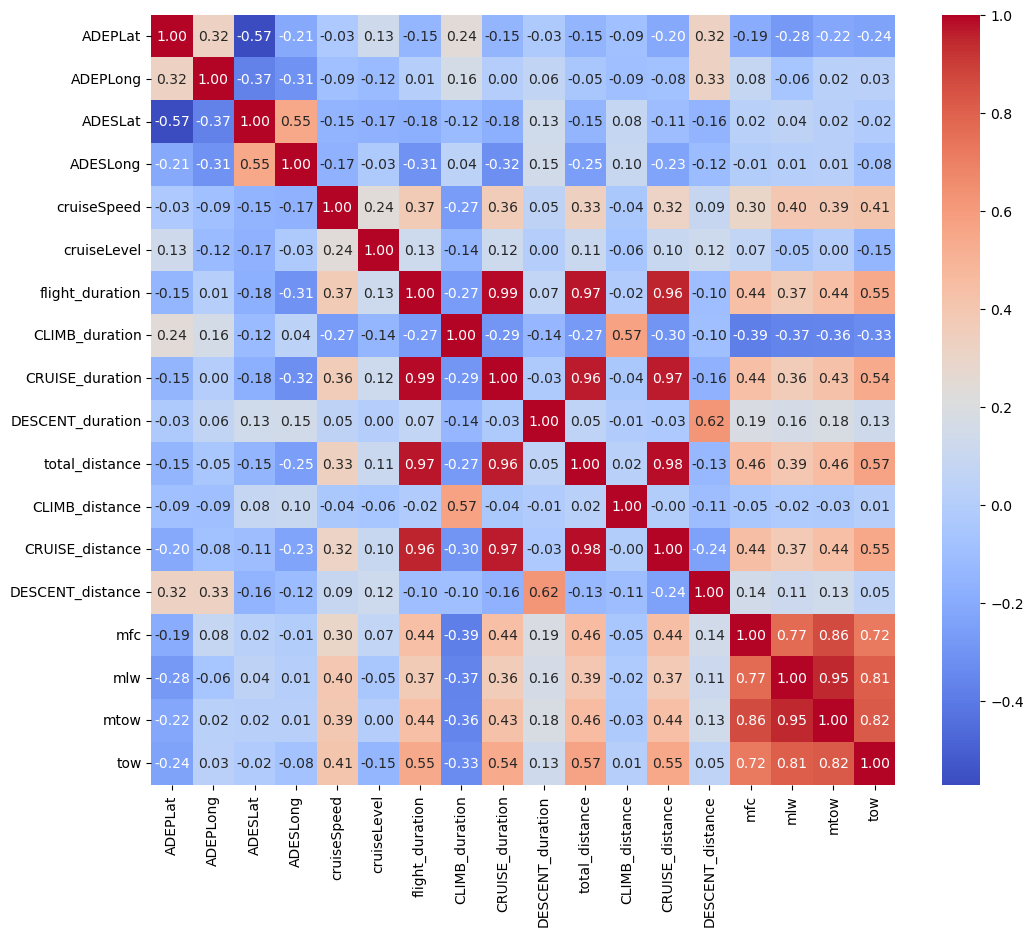

In [12]:
subset = ['ADEPLat', 'ADEPLong', 'ADESLat', 'ADESLong', 'cruiseSpeed', 'cruiseLevel', 'flight_duration', 'CLIMB_duration', 'CRUISE_duration', 'DESCENT_duration', 'total_distance', 'CLIMB_distance', 'CRUISE_distance', 'DESCENT_distance', 'mfc', 'mlw', 'mtow', 'tow']
data[subset] = scaler.fit_transform(data[subset])
spearman_corr = data[subset].corr(method='spearman')
plt.figure(figsize=(12, 10))
sns.heatmap(spearman_corr, annot=True, fmt=".2f", cmap="coolwarm")
# plt.title("Spearman Correlation Matrix")
plt.show()

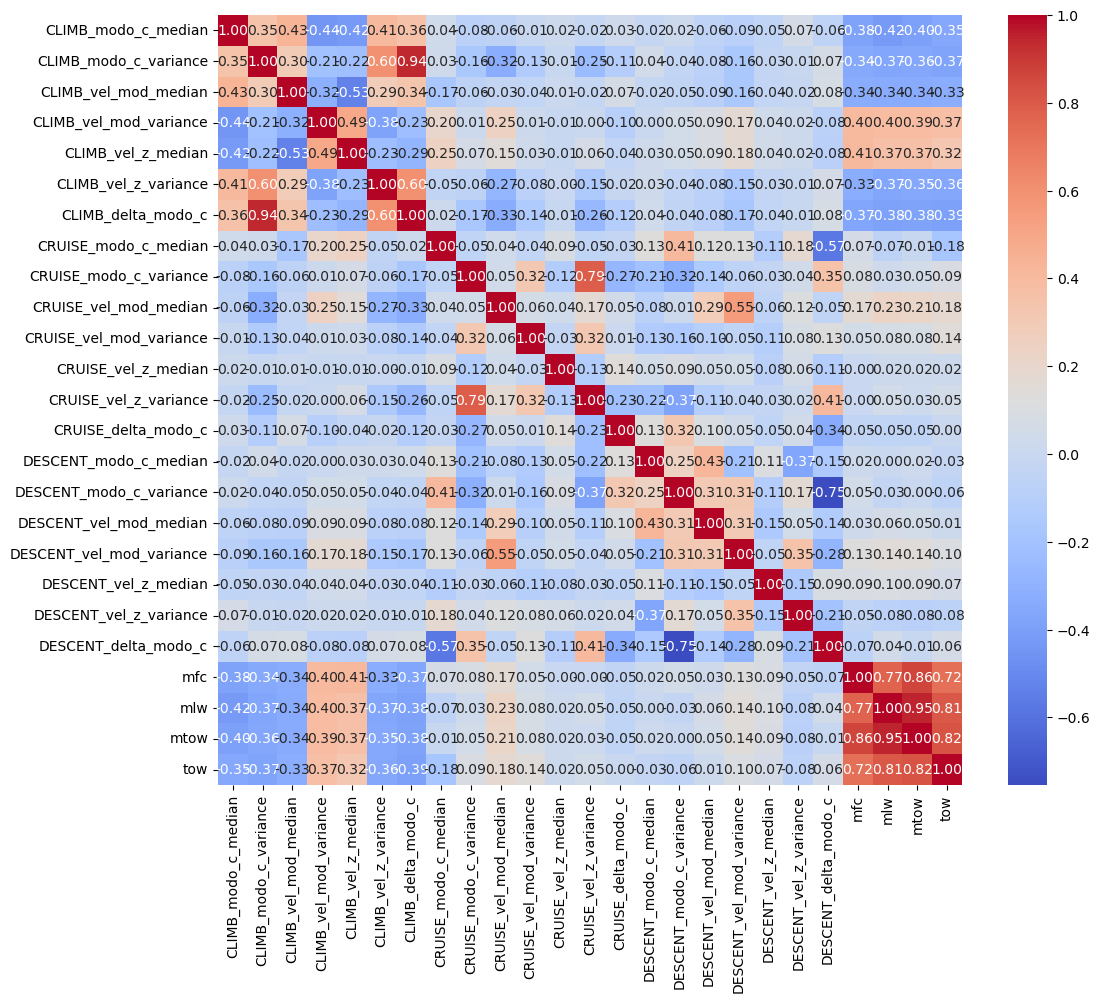

In [13]:
subset = ['CLIMB_modo_c_median', 'CLIMB_modo_c_variance', 'CLIMB_vel_mod_median', 'CLIMB_vel_mod_variance', 'CLIMB_vel_z_median', 'CLIMB_vel_z_variance', 'CLIMB_delta_modo_c', 'CRUISE_modo_c_median', 'CRUISE_modo_c_variance', 'CRUISE_vel_mod_median', 'CRUISE_vel_mod_variance', 'CRUISE_vel_z_median', 'CRUISE_vel_z_variance', 'CRUISE_delta_modo_c', 'DESCENT_modo_c_median', 'DESCENT_modo_c_variance', 'DESCENT_vel_mod_median', 'DESCENT_vel_mod_variance', 'DESCENT_vel_z_median', 'DESCENT_vel_z_variance', 'DESCENT_delta_modo_c', 'mfc', 'mlw', 'mtow', 'tow']
data[subset] = scaler.fit_transform(data[subset])
spearman_corr = data[subset].corr(method='spearman')
plt.figure(figsize=(12, 10))
sns.heatmap(spearman_corr, annot=True, fmt=".2f", cmap="coolwarm")
# plt.title("Spearman Correlation Matrix")
plt.show()

In [15]:
subset = [
 'CLIMB_vel_mod_mean_0_30fl',
 'CLIMB_vel_mod_variance_0_30fl',
 'CLIMB_vel_z_mean_0_30fl',
 'CLIMB_vel_z_variance_0_30fl',
 'CLIMB_vel_mod_mean_0_60fl',
 'CLIMB_vel_mod_variance_0_60fl',
 'CLIMB_vel_z_mean_0_60fl',
 'CLIMB_vel_z_variance_0_60fl',
 'CLIMB_vel_mod_mean_0_90fl',
 'CLIMB_vel_mod_variance_0_90fl',
 'CLIMB_vel_z_mean_0_90fl',
 'CLIMB_vel_z_variance_0_90fl',
 'CLIMB_vel_mod_mean_30_60fl',
 'CLIMB_vel_mod_variance_30_60fl',
 'CLIMB_vel_z_mean_30_60fl',
 'CLIMB_vel_z_variance_30_60fl',
 'CLIMB_vel_mod_mean_30_90fl',
 'CLIMB_vel_mod_variance_30_90fl',
 'CLIMB_vel_z_mean_30_90fl',
 'CLIMB_vel_z_variance_30_90fl',
 'CLIMB_vel_mod_mean_60_90fl',
 'CLIMB_vel_mod_variance_60_90fl',
 'CLIMB_vel_z_mean_60_90fl',
 'CLIMB_vel_z_variance_60_90fl',
 'mfc', 'mlw', 'mtow', 'tow'
]
data[subset] = scaler.fit_transform(data[subset])
spearman_corr = data[subset].corr(method='spearman')
plt.figure(figsize=(14, 12))
sns.heatmap(spearman_corr, annot=True, fmt=".2f", cmap="coolwarm")
# plt.title("Spearman Correlation Matrix")
plt.show()

KeyError: "['CLIMB_vel_mod_mean_0_30fl', 'CLIMB_vel_mod_variance_0_30fl', 'CLIMB_vel_z_mean_0_30fl', 'CLIMB_vel_z_variance_0_30fl', 'CLIMB_vel_mod_mean_0_60fl', 'CLIMB_vel_mod_variance_0_60fl', 'CLIMB_vel_z_mean_0_60fl', 'CLIMB_vel_z_variance_0_60fl', 'CLIMB_vel_mod_mean_0_90fl', 'CLIMB_vel_mod_variance_0_90fl', 'CLIMB_vel_z_mean_0_90fl', 'CLIMB_vel_z_variance_0_90fl', 'CLIMB_vel_mod_mean_30_60fl', 'CLIMB_vel_mod_variance_30_60fl', 'CLIMB_vel_z_mean_30_60fl', 'CLIMB_vel_z_variance_30_60fl', 'CLIMB_vel_mod_mean_30_90fl', 'CLIMB_vel_mod_variance_30_90fl', 'CLIMB_vel_z_mean_30_90fl', 'CLIMB_vel_z_variance_30_90fl', 'CLIMB_vel_mod_mean_60_90fl', 'CLIMB_vel_mod_variance_60_90fl', 'CLIMB_vel_z_mean_60_90fl', 'CLIMB_vel_z_variance_60_90fl'] not in index"

## Polynomial (with Pearson)

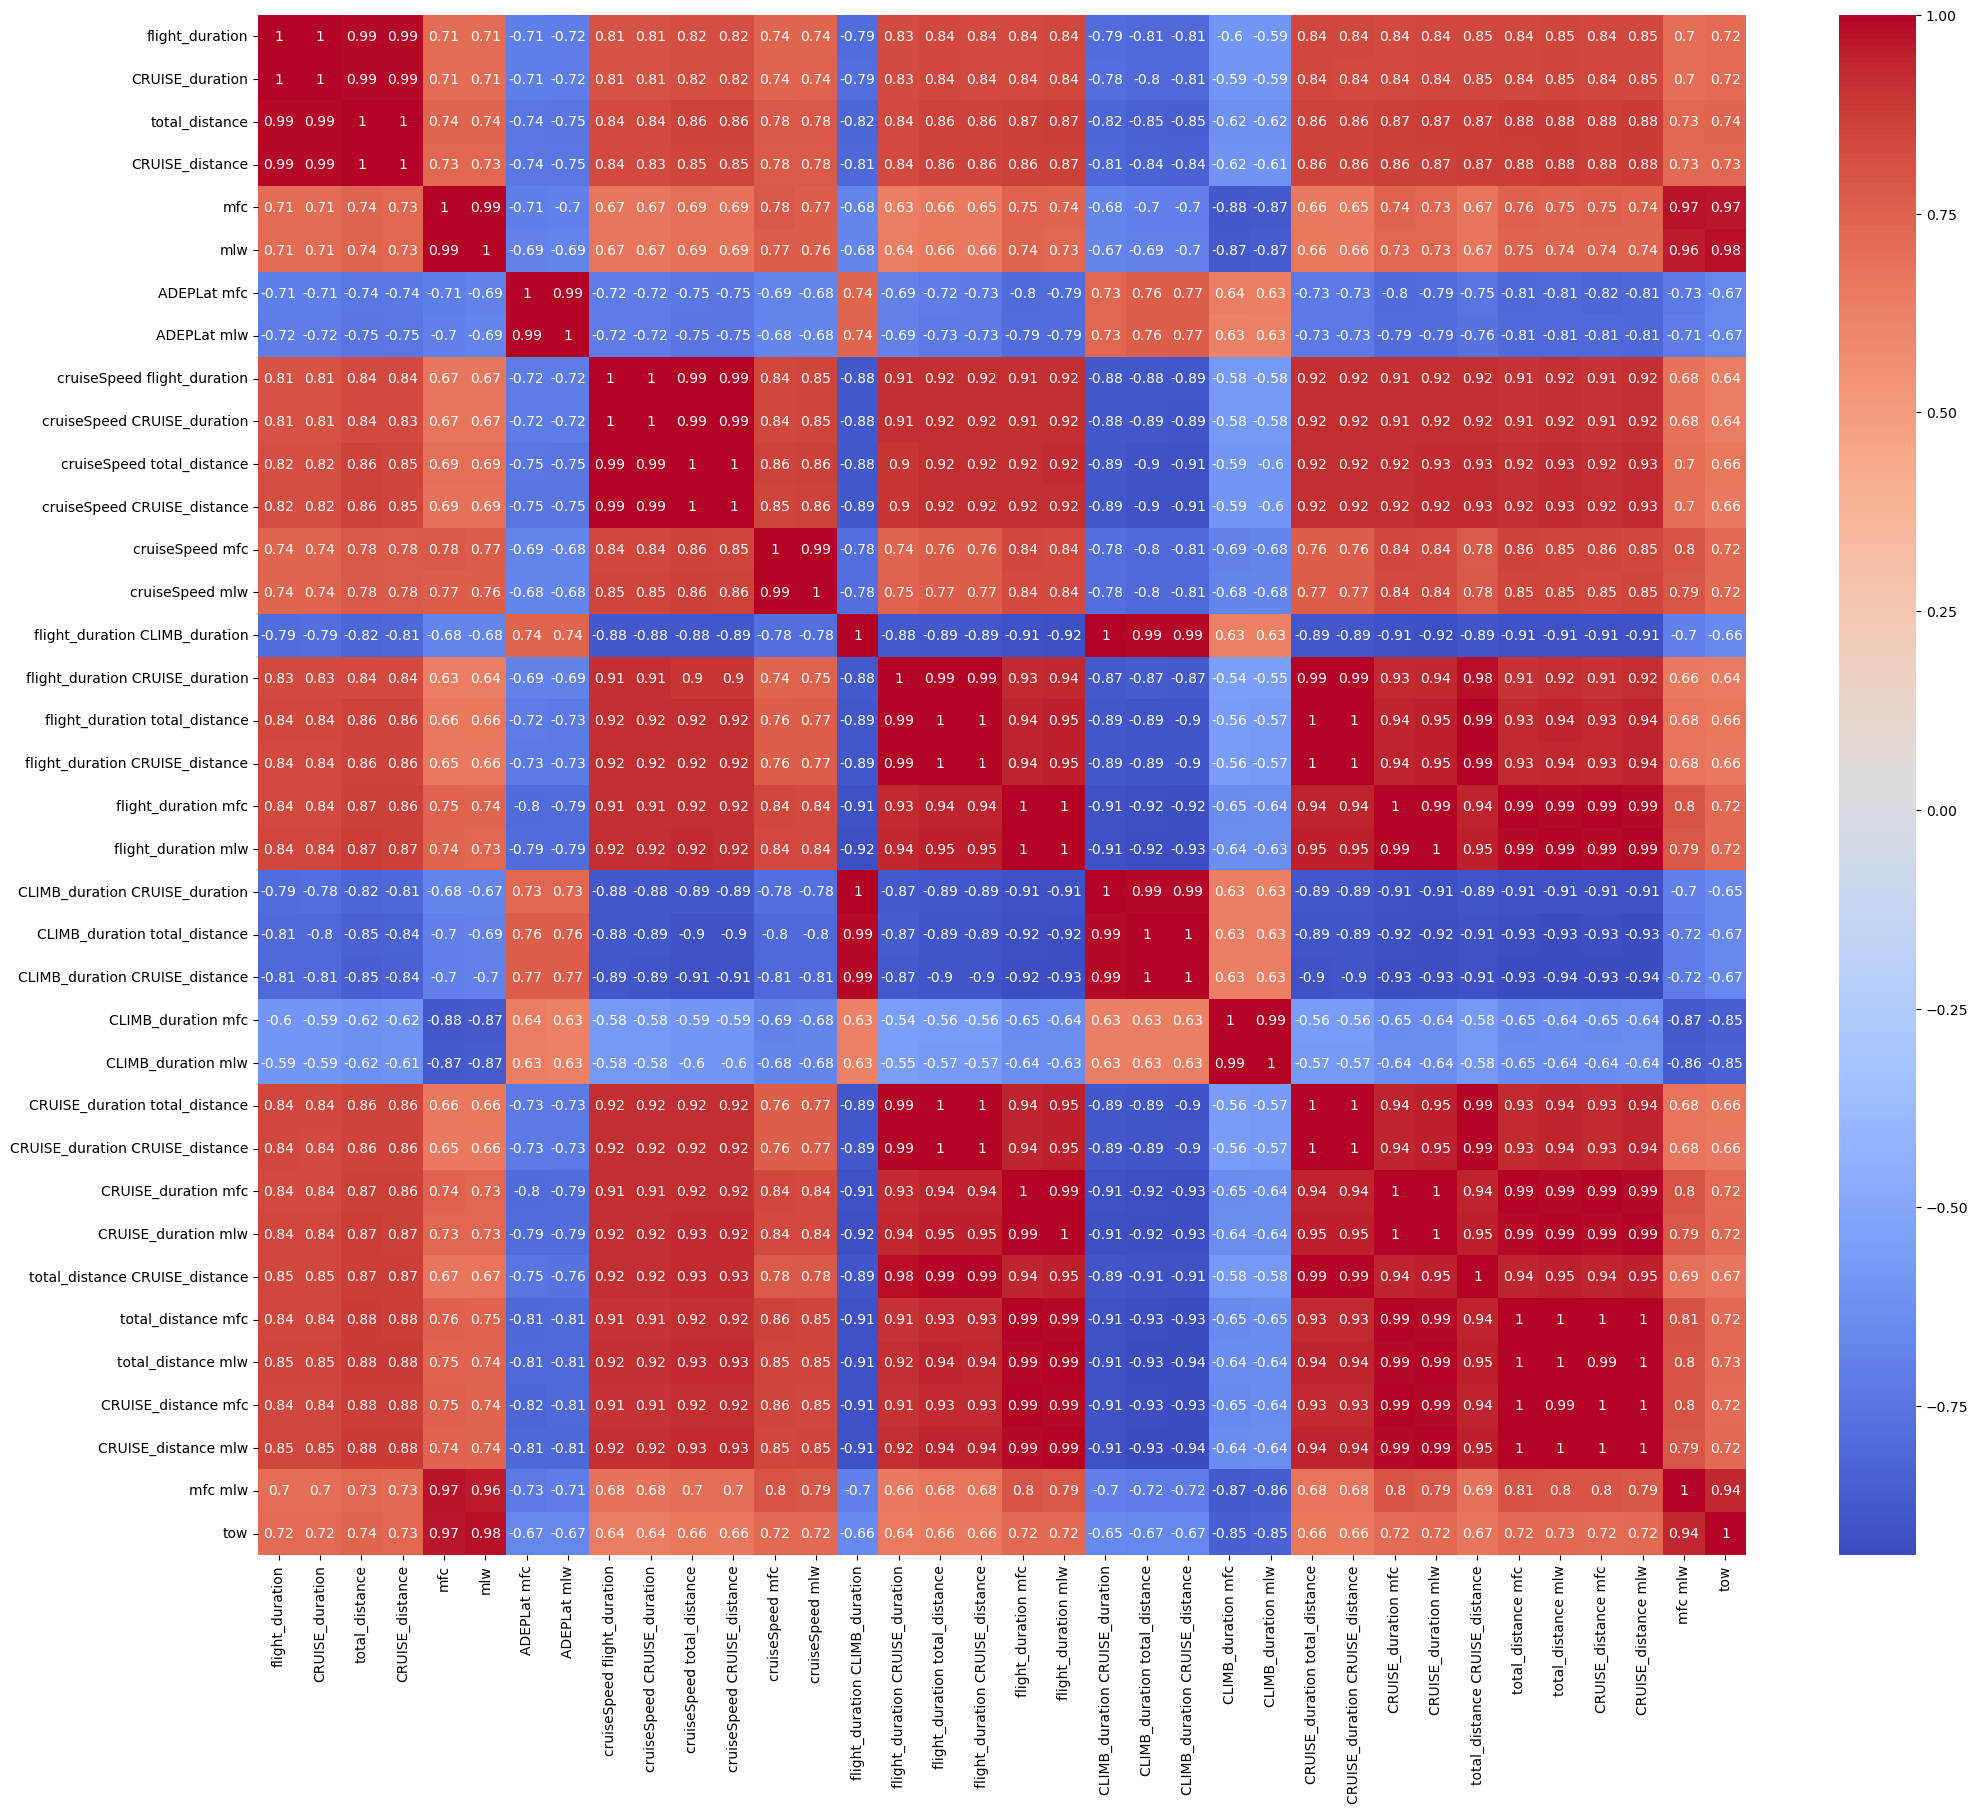

In [16]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)

subset = ['ADEPLat', 'ADEPLong', 'ADESLat', 'ADESLong', 'cruiseSpeed', 'cruiseLevel', 'flight_duration', 'CLIMB_duration', 'CRUISE_duration', 'DESCENT_duration', 'total_distance', 'CLIMB_distance', 'CRUISE_distance', 'DESCENT_distance', 'mfc', 'mlw', 'mtow', 'tow']

data[subset] = scaler.fit_transform(data[subset])
poly_features = poly.fit_transform(X=data[subset])

poly_feature_names = poly.get_feature_names_out(subset)
poly_features_df = pd.DataFrame(poly_features, columns=poly_feature_names)

poly_corr = poly_features_df.corr(method='pearson')
selected_cols = [
    col for col in poly_corr.columns 
    if abs(poly_corr.loc['tow', col]) > 0.6 and (col == 'tow' or 'tow' not in col)
]
poly_corr_filtered = poly_corr.loc[selected_cols, selected_cols]

# Step 1: Get the list of current indices (row names)
current_indices = poly_corr_filtered.index.tolist()

# Step 2: Remove "tow" from its current position
current_indices.remove("tow")

# Step 3: Add "tow" to the end
current_indices.append("tow")

# Step 4: Reindex the DataFrame with the new order
poly_corr_filtered = poly_corr_filtered.reindex(current_indices)

# If you also want to reorder the columns the same way (common for correlation matrices)
poly_corr_filtered = poly_corr_filtered.reindex(columns=current_indices)

plt.figure(figsize=(24, 20))
sns.heatmap(poly_corr_filtered, cmap="coolwarm", annot=True)
plt.show()

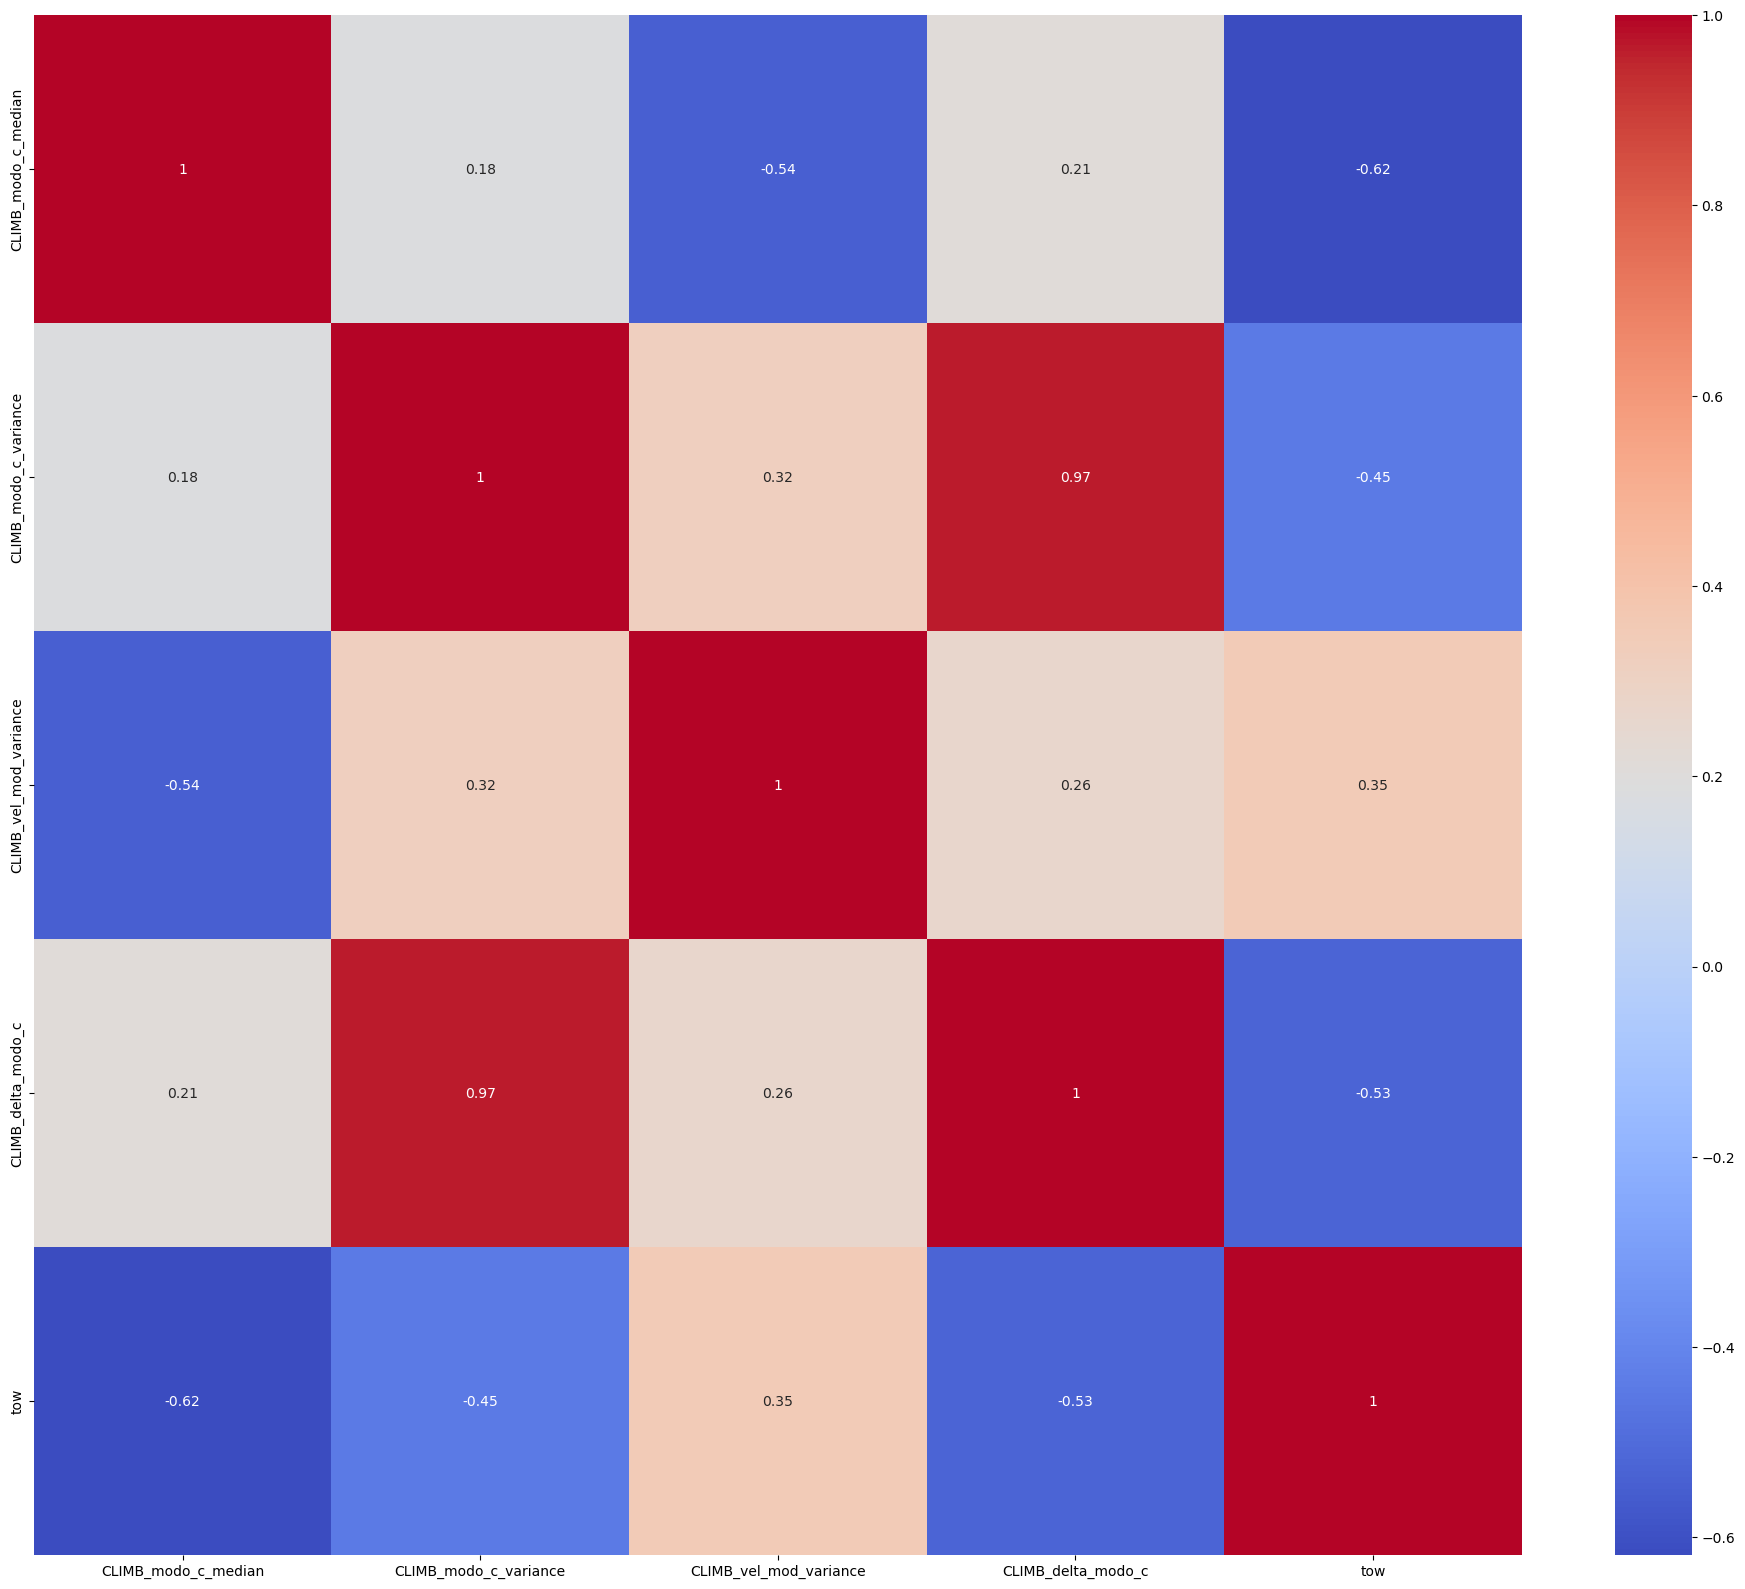

In [177]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)


subset = ['CLIMB_modo_c_median', 'CLIMB_modo_c_variance', 'CLIMB_vel_mod_median', 'CLIMB_vel_mod_variance', 'CLIMB_vel_z_median', 'CLIMB_vel_z_variance', 'CLIMB_delta_modo_c', 'tow']

# subset = ['CLIMB_modo_c_median', 'CLIMB_modo_c_variance', 'CLIMB_vel_mod_median', 'CLIMB_vel_mod_variance', 'CLIMB_vel_z_median', 'CLIMB_vel_z_variance', 'CLIMB_delta_modo_c', 'CRUISE_modo_c_median', 'CRUISE_modo_c_variance', 'CRUISE_vel_mod_median', 'CRUISE_vel_mod_variance', 'CRUISE_vel_z_median', 'CRUISE_vel_z_variance', 'CRUISE_delta_modo_c', 'DESCENT_modo_c_median', 'DESCENT_modo_c_variance', 'DESCENT_vel_mod_median', 'DESCENT_vel_mod_variance', 'DESCENT_vel_z_median', 'DESCENT_vel_z_variance', 'DESCENT_delta_modo_c', 'tow']


data[subset] = scaler.fit_transform(data[subset])
poly_features = poly.fit_transform(X=data[subset])

poly_feature_names = poly.get_feature_names_out(subset)
poly_features_df = pd.DataFrame(poly_features, columns=poly_feature_names)

poly_corr = poly_features_df.corr(method='pearson')

selected_cols = [
    col for col in poly_corr.columns 
    if abs(poly_corr.loc['tow', col]) > 0.3 and (col == 'tow' or 'tow' not in col)
]
poly_corr_filtered = poly_corr.loc[selected_cols, selected_cols]

plt.figure(figsize=(24, 20))
sns.heatmap(poly_corr_filtered, cmap="coolwarm", annot=True)
plt.show()

# plt.figure(figsize=(24, 20))
# sns.heatmap(poly_corr, cmap="coolwarm", annot=True)
# plt.show()

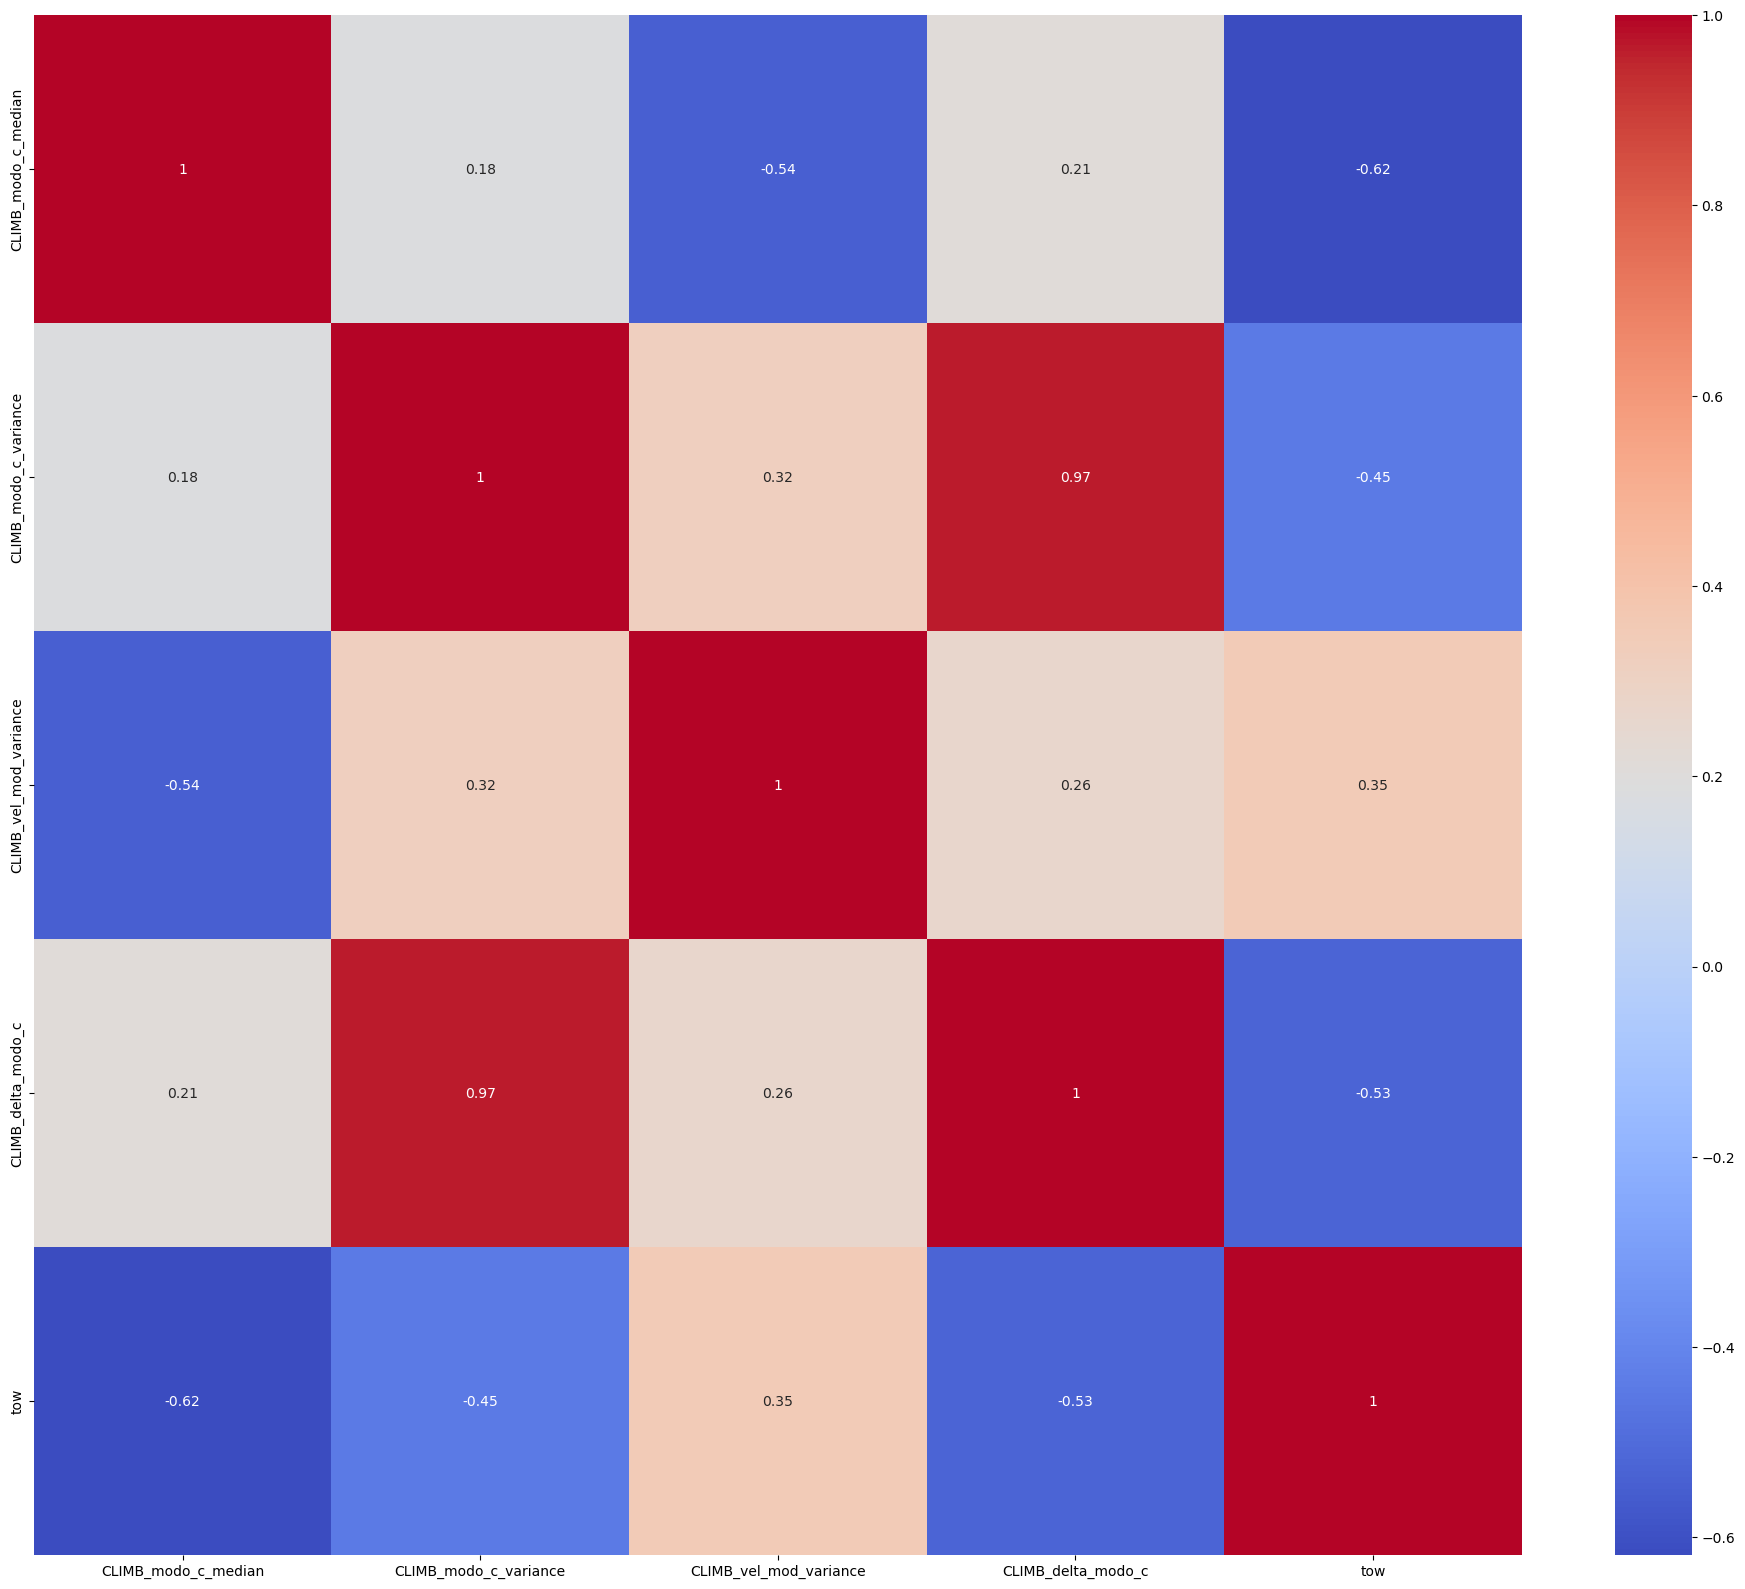

In [179]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)


subset = ['CRUISE_modo_c_median', 'CRUISE_modo_c_variance', 'CRUISE_vel_mod_median', 'CRUISE_vel_mod_variance', 'CRUISE_vel_z_median', 'CRUISE_vel_z_variance', 'CRUISE_delta_modo_c', 'tow']

# subset = ['DESCENT_modo_c_median', 'DESCENT_modo_c_variance', 'DESCENT_vel_mod_median', 'DESCENT_vel_mod_variance', 'DESCENT_vel_z_median', 'DESCENT_vel_z_variance', 'DESCENT_delta_modo_c', 'tow']


data[subset] = scaler.fit_transform(data[subset])
poly_features = poly.fit_transform(X=data[subset])

poly_feature_names = poly.get_feature_names_out(subset)
poly_features_df = pd.DataFrame(poly_features, columns=poly_feature_names)

poly_corr = poly_features_df.corr(method='pearson')

selected_cols = [
    col for col in poly_corr.columns 
    if abs(poly_corr.loc['tow', col]) > 0.3 and (col == 'tow' or 'tow' not in col)
]
# poly_corr_filtered = poly_corr.loc[selected_cols, selected_cols]

# Step 1: Get the list of current indices (row names)
current_indices = poly_corr_filtered.index.tolist()

# Step 2: Remove "tow" from its current position
current_indices.remove("tow")

# Step 3: Add "tow" to the end
current_indices.append("tow")

# Step 4: Reindex the DataFrame with the new order
poly_corr_filtered = poly_corr_filtered.reindex(current_indices)

# If you also want to reorder the columns the same way (common for correlation matrices)
poly_corr_filtered = poly_corr_filtered.reindex(columns=current_indices)


plt.figure(figsize=(24, 20))
sns.heatmap(poly_corr_filtered, cmap="coolwarm", annot=True)
plt.show()

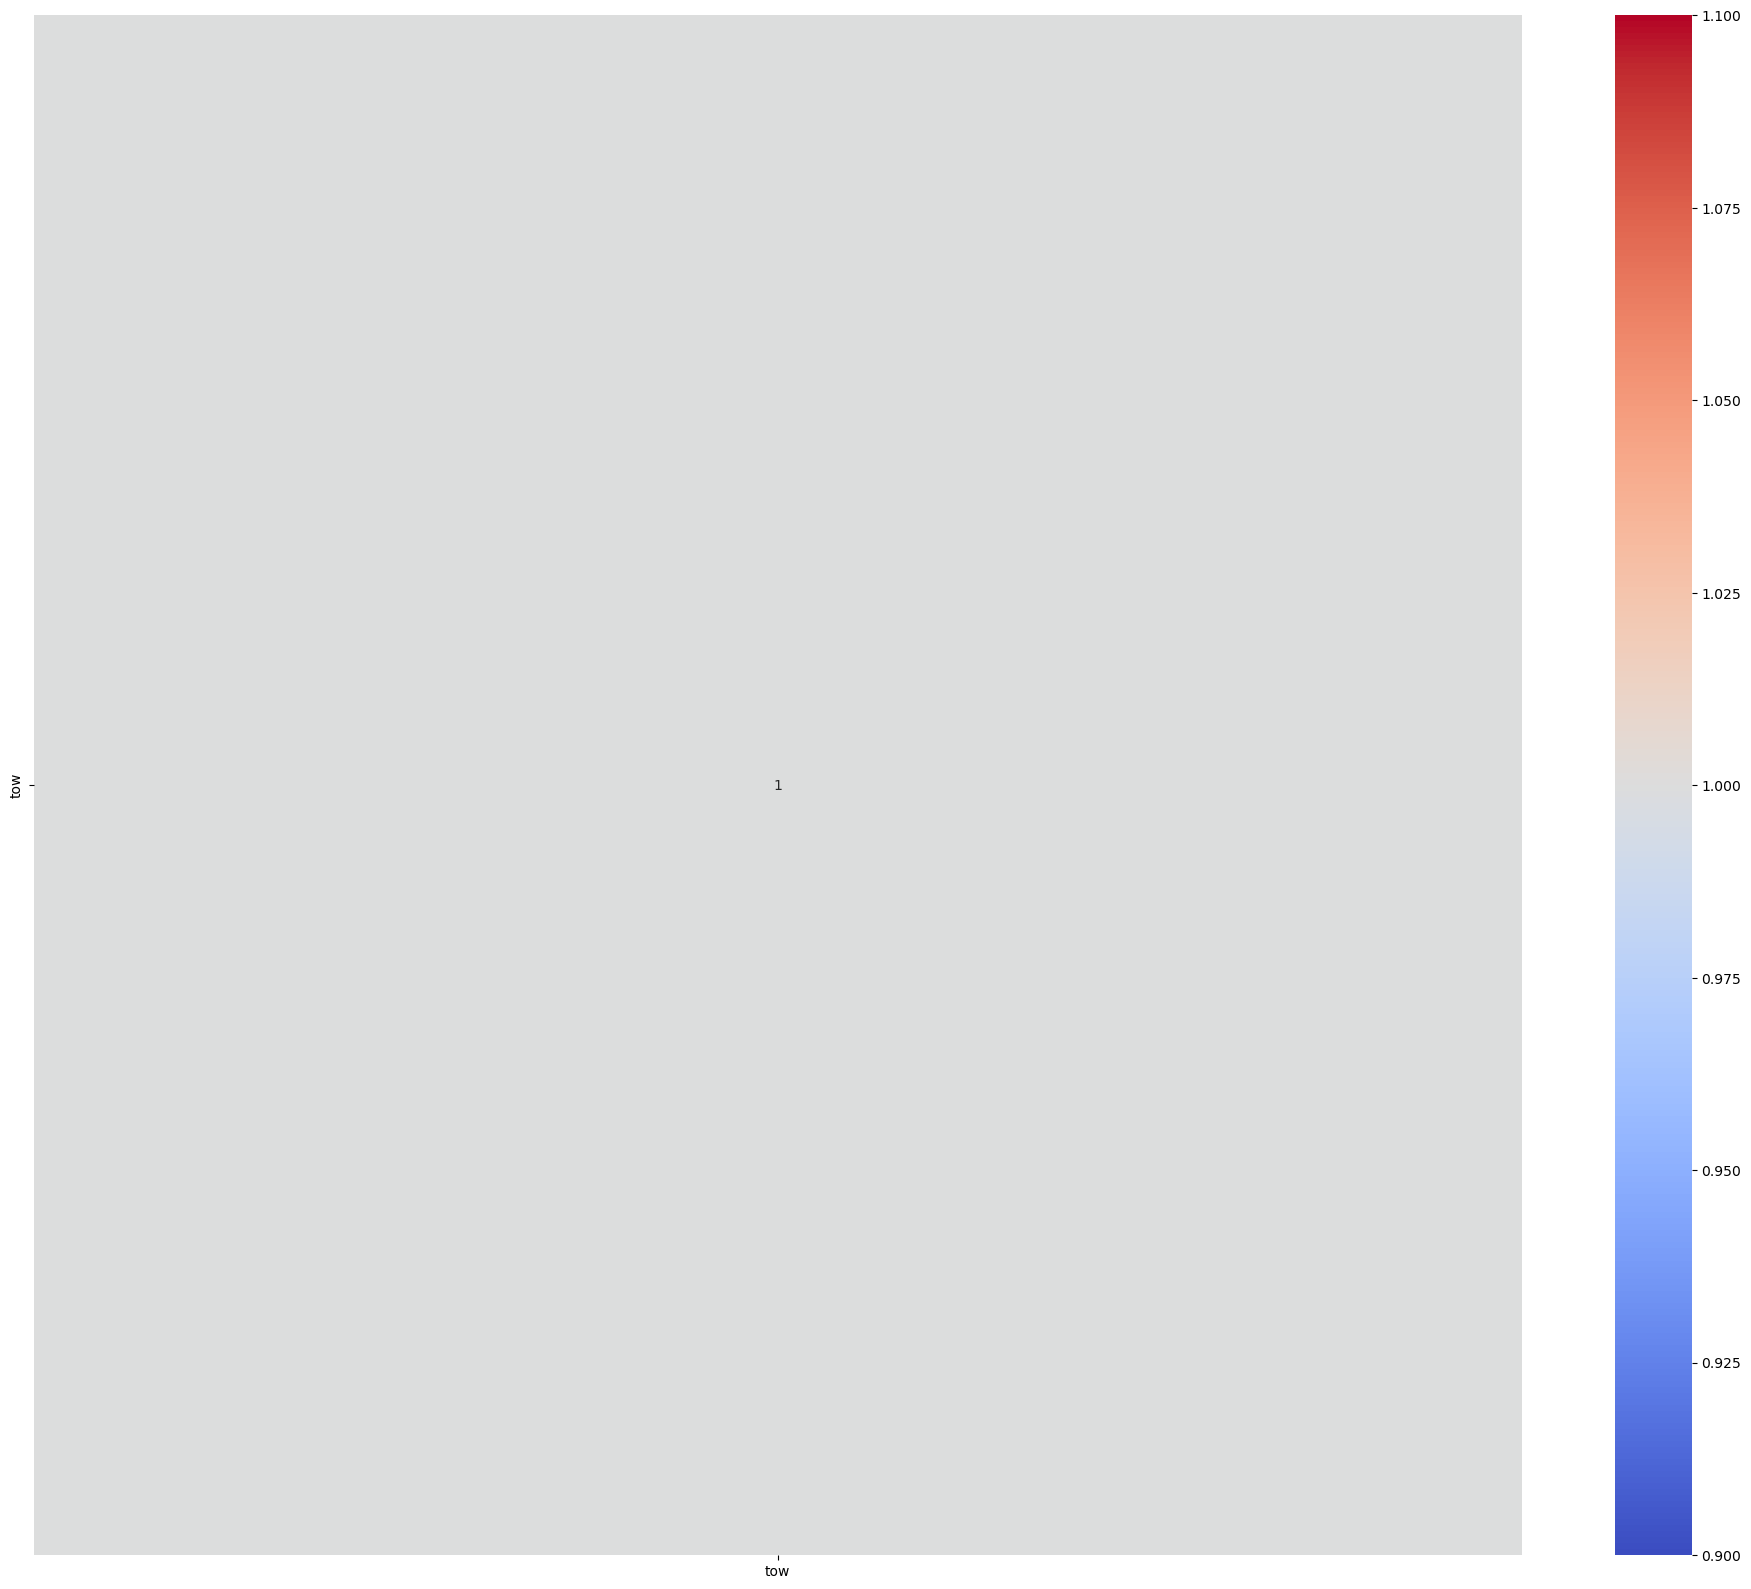

In [180]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)

subset = ['DESCENT_modo_c_median', 'DESCENT_modo_c_variance', 'DESCENT_vel_mod_median', 'DESCENT_vel_mod_variance', 'DESCENT_vel_z_median', 'DESCENT_vel_z_variance', 'DESCENT_delta_modo_c', 'tow']


data[subset] = scaler.fit_transform(data[subset])
poly_features = poly.fit_transform(X=data[subset])

poly_feature_names = poly.get_feature_names_out(subset)
poly_features_df = pd.DataFrame(poly_features, columns=poly_feature_names)

poly_corr = poly_features_df.corr(method='pearson')

selected_cols = [
    col for col in poly_corr.columns 
    if abs(poly_corr.loc['tow', col]) > 0.3 and (col == 'tow' or 'tow' not in col)
]
poly_corr_filtered = poly_corr.loc[selected_cols, selected_cols]

# plt.figure(figsize=(24, 20))
# sns.heatmap(poly_corr_filtered, cmap="coolwarm", annot=True)
# plt.show()

plt.figure(figsize=(24, 20))
sns.heatmap(poly_corr_filtered, cmap="coolwarm", annot=True)
plt.show()

In [41]:
# from sklearn.preprocessing import PolynomialFeatures

# poly = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)

# subset = ['CLIMB_modo_c_median', 'CLIMB_modo_c_variance', 'CLIMB_vel_mod_median', 'CLIMB_vel_mod_variance', 'CLIMB_vel_z_median', 'CLIMB_vel_z_variance', 'CLIMB_delta_modo_c', 'CRUISE_modo_c_median', 'CRUISE_modo_c_variance', 'CRUISE_vel_mod_median', 'CRUISE_vel_mod_variance', 'CRUISE_vel_z_median', 'CRUISE_vel_z_variance', 'CRUISE_delta_modo_c', 'DESCENT_modo_c_median', 'DESCENT_modo_c_variance', 'DESCENT_vel_mod_median', 'DESCENT_vel_mod_variance', 'DESCENT_vel_z_median', 'DESCENT_vel_z_variance', 'DESCENT_delta_modo_c', 'tow']


# data[subset] = scaler.fit_transform(data[subset])
# poly_features = poly.fit_transform(X=data[subset])

# poly_feature_names = poly.get_feature_names_out(subset)
# poly_features_df = pd.DataFrame(poly_features, columns=poly_feature_names)

# poly_corr = poly_features_df.corr(method='pearson')

# selected_cols = [
#     col for col in poly_corr.columns 
#     if abs(poly_corr.loc['tow', col]) > 0.6 and (col == 'tow' or 'tow' not in col)
# ]
# poly_corr_filtered = poly_corr.loc[selected_cols, selected_cols]

# plt.figure(figsize=(24, 20))
# sns.heatmap(poly_corr_filtered, cmap="coolwarm", annot=True)
# plt.show()

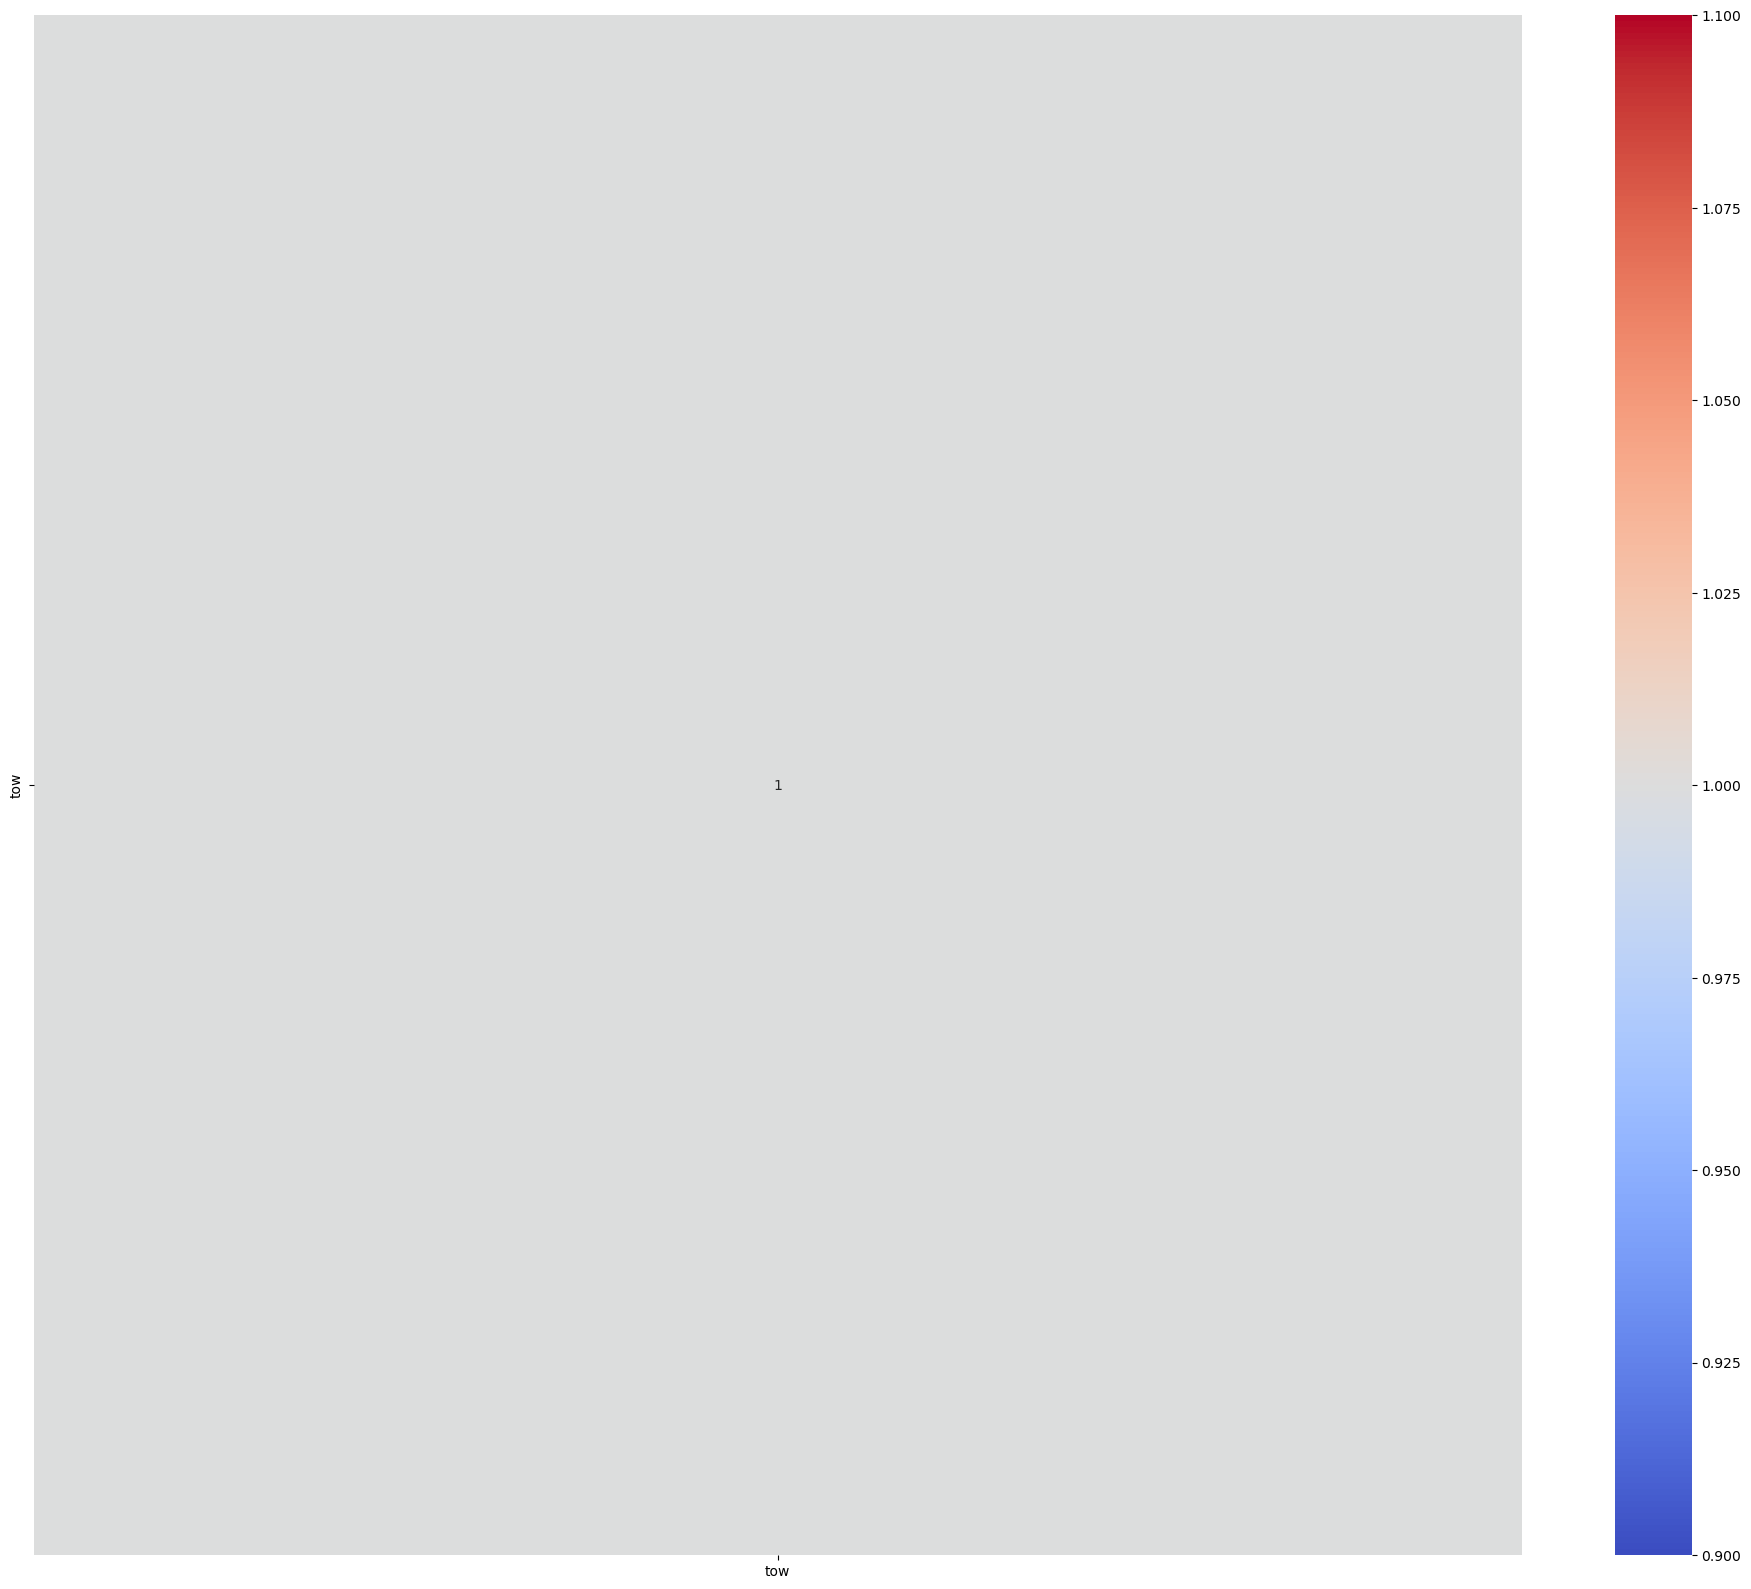

In [181]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)

subset = [
 'CLIMB_vel_mod_mean_0-30fl',
 'CLIMB_vel_mod_variance_0-30fl',
 'CLIMB_vel_z_mean_0-30fl',
 'CLIMB_vel_z_variance_0-30fl',
 'CLIMB_vel_mod_mean_0-60fl',
 'CLIMB_vel_mod_variance_0-60fl',
 'CLIMB_vel_z_mean_0-60fl',
 'CLIMB_vel_z_variance_0-60fl',
 'CLIMB_vel_mod_mean_0-90fl',
 'CLIMB_vel_mod_variance_0-90fl',
 'CLIMB_vel_z_mean_0-90fl',
 'CLIMB_vel_z_variance_0-90fl',
 'CLIMB_vel_mod_mean_30-60fl',
 'CLIMB_vel_mod_variance_30-60fl',
 'CLIMB_vel_z_mean_30-60fl',
 'CLIMB_vel_z_variance_30-60fl',
 'CLIMB_vel_mod_mean_30-90fl',
 'CLIMB_vel_mod_variance_30-90fl',
 'CLIMB_vel_z_mean_30-90fl',
 'CLIMB_vel_z_variance_30-90fl',
 'CLIMB_vel_mod_mean_60-90fl',
 'CLIMB_vel_mod_variance_60-90fl',
 'CLIMB_vel_z_mean_60-90fl',
 'CLIMB_vel_z_variance_60-90fl',
 'tow'
]

climb_data = data[subset].copy()
climb_data = climb_data.dropna()
climb_data = scaler.fit_transform(climb_data)
poly_features = poly.fit_transform(X=climb_data)

poly_feature_names = poly.get_feature_names_out(subset)
poly_features_df = pd.DataFrame(poly_features, columns=poly_feature_names)
poly_corr = poly_features_df.corr(method='pearson')

selected_cols = [
    col for col in poly_corr.columns 
    if abs(poly_corr.loc['tow', col]) > 0.3 and (col == 'tow' or 'tow' not in col)
]
poly_corr_filtered = poly_corr.loc[selected_cols, selected_cols]

plt.figure(figsize=(24, 20))
sns.heatmap(poly_corr_filtered, cmap="coolwarm", annot=True)
plt.show()

# tow

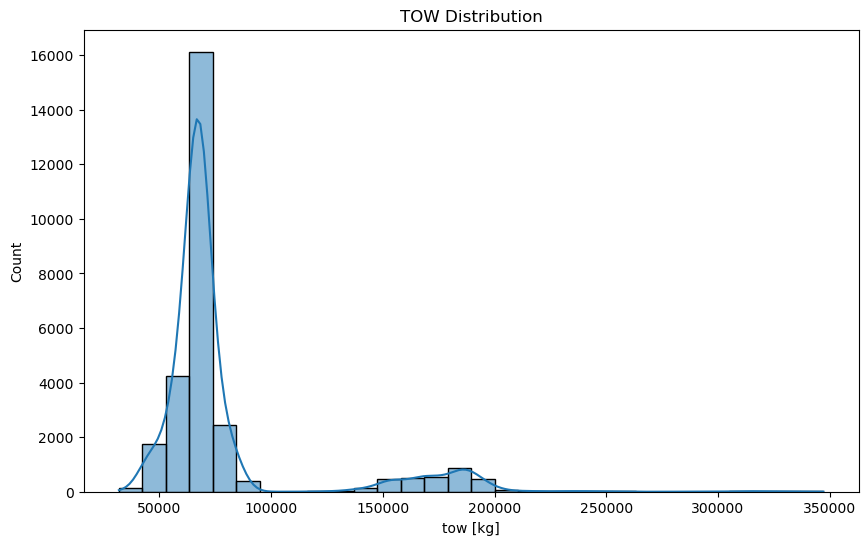

In [53]:
plt.figure(figsize=(10,6))
sns.histplot(data['tow'], kde=True, bins=30)
plt.title("TOW Distribution")
plt.xlabel("tow [kg]")
plt.ylabel("Count")
plt.show()

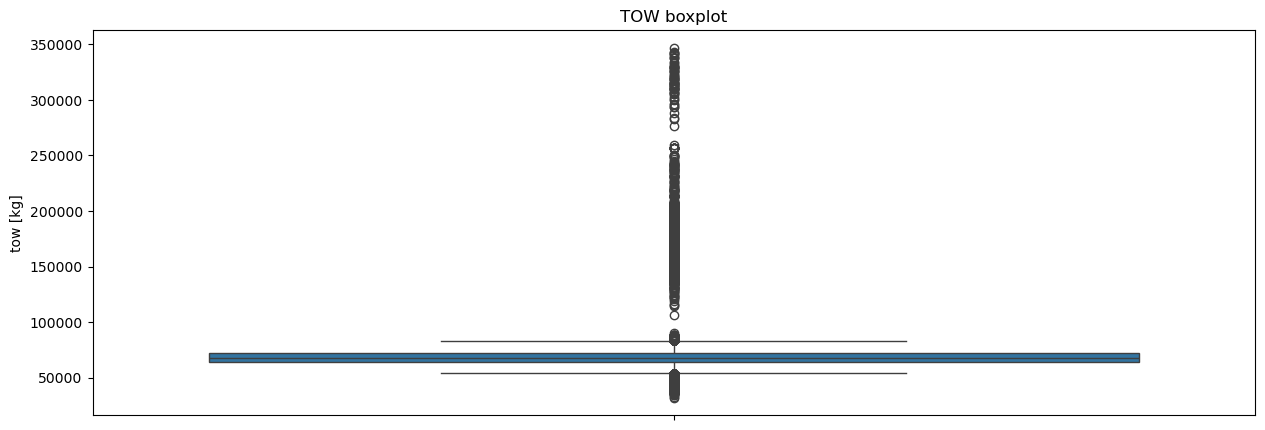

In [47]:
plt.figure(figsize=(15,5))
sns.boxplot(y=data['tow'])
plt.ylabel("tow [kg]")
plt.title("TOW boxplot")
plt.show()

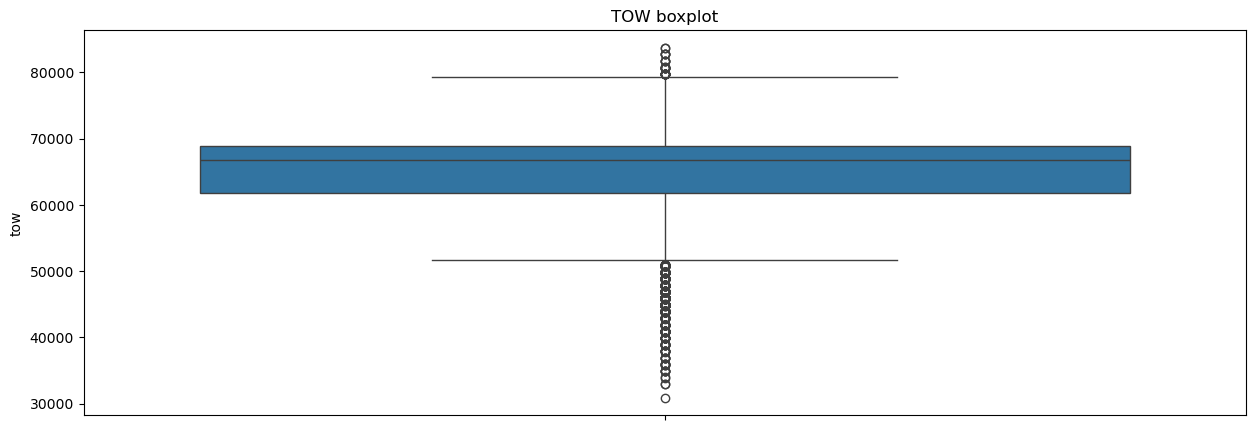

In [8]:
plt.figure(figsize=(15,5))
sns.boxplot(y=data[data['tow'] < 100000]['tow'])
plt.title("TOW boxplot")
plt.show()